# <center>Data Mining Project Notebook</center>

## <center>From Data to Destinations: Segmenting AIAI’s Customers for Smarter Decisions</center>

<br>

## <center>*Group 46*</center>

**Prepared by:**  
- Batoul Abdullah (20250536)  
- Joel Clemen-Holder (20250538)  
- Henrique João Monteiro Simões Álvares Serrão (20250359)

---

## Table of Contents

1. [Exploratory Data Analysis (EDA)](#1-exploratory-data-analysis-eda)  
2. [Data Cleaning and Preprocessing](#2-data-cleaning-and-preprocessing)  
3. [Deep Analysis and Feature Engineering](#3-deep-analysis-and-feature-engineering)  
4. [Feature Selection](#4-feature-selection)  
5. [Clustering Methods and Results](#5-clustering-methods-and-results)  
6. [Final Insights and Business Recommendations](#6-final-insights-and-business-recommendations)

---


# 1.Exploratory Data Analysis (EDA)

In [2]:
#importing needed libraries 

In [3]:
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from scipy.stats import skewnorm
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import os, warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings('ignore')

In [4]:
#importing the two datasets :

In [5]:
customers = pd.read_csv("DM_AIAI_CustomerDB (1).csv")
flights = pd.read_csv("DM_AIAI_FlightsDB (1).csv")

In [6]:
#checking the characteristics of the data :

In [7]:
customers.shape

(16921, 21)

In [8]:
flights.shape

(608436, 10)

In [9]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16921 entries, 0 to 16920
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               16921 non-null  int64  
 1   Loyalty#                 16921 non-null  int64  
 2   First Name               16921 non-null  object 
 3   Last Name                16921 non-null  object 
 4   Customer Name            16921 non-null  object 
 5   Country                  16921 non-null  object 
 6   Province or State        16921 non-null  object 
 7   City                     16921 non-null  object 
 8   Latitude                 16921 non-null  float64
 9   Longitude                16921 non-null  float64
 10  Postal code              16921 non-null  object 
 11  Gender                   16921 non-null  object 
 12  Education                16921 non-null  object 
 13  Location Code            16921 non-null  object 
 14  Income                

In [10]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [11]:
#checking the datatypes :

In [12]:
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [13]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

In [14]:
customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


In [15]:
flights.head()

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
0,413052,2021,12,12/1/2021,2.0,2.0,9384.0,938.0,0.0,0.0
1,464105,2021,12,12/1/2021,0.0,0.0,0.0,0.0,0.0,0.0
2,681785,2021,12,12/1/2021,10.0,3.0,14745.0,1474.0,0.0,0.0
3,185013,2021,12,12/1/2021,16.0,4.0,26311.0,2631.0,3213.0,32.0
4,216596,2021,12,12/1/2021,9.0,0.0,19275.0,1927.0,0.0,0.0


In [16]:
# checking data types :

In [17]:
customers.dtypes

Unnamed: 0                   int64
Loyalty#                     int64
First Name                  object
Last Name                   object
Customer Name               object
Country                     object
Province or State           object
City                        object
Latitude                   float64
Longitude                  float64
Postal code                 object
Gender                      object
Education                   object
Location Code               object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [18]:
flights.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
YearMonthDate                object
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

In [19]:
#checking the duplicates for both datasets :

In [20]:
flights.duplicated().sum()

np.int64(2903)

In [21]:
customers.duplicated().sum()

np.int64(0)

In [22]:
#checking the duplicates for #Loyalty as it is the identifier and should not has ducplicates  :

In [23]:
customers['Loyalty#'].duplicated().sum()

np.int64(164)

In [24]:
flights['Loyalty#'].duplicated().sum()

np.int64(591699)

we identified that , flights dataset has duplications in the #Loyalty  ,FlightsDB is at monthly granularity, so multiple records per customer are expected.we have to explore more in case we need to remove them in the next stages

In [25]:
#checking the missing values :

In [26]:
customers.isna().sum()

Unnamed: 0                     0
Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [27]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [28]:
## descriptive statistics :

In [29]:
customers.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,NaN,NaN,NaN,8440.023639,4884.775439,0.0,4210.0,8440.0,12670.0,16900.0
Loyalty#,16921.0,NaN,NaN,NaN,550197.393771,259251.503597,100011.0,326823.0,550896.0,772438.0,999999.0
First Name,16921,4941,Deon,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,16921,15404,Salberg,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Name,16921,16921,Emma Martin,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,16921,1,Canada,16921,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province or State,16921,11,Ontario,5468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,16921,29,Toronto,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,16921.0,NaN,NaN,NaN,47.1745,3.307971,42.984924,44.231171,46.087818,49.28273,60.721188
Longitude,16921.0,NaN,NaN,NaN,-91.814768,22.242429,-135.05684,-120.23766,-79.383186,-74.596184,-52.712578


In [30]:
flights.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,NaN,NaN,NaN,550037.873084,258935.180575,100018.0,326961.0,550834.0,772194.0,999986.0
Year,608436.0,NaN,NaN,NaN,2020.0,0.816497,2019.0,2019.0,2020.0,2021.0,2021.0
Month,608436.0,NaN,NaN,NaN,6.5,3.452055,1.0,3.75,6.5,9.25,12.0
YearMonthDate,608436,36,12/1/2021,16901,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumFlights,608436.0,NaN,NaN,NaN,3.908107,5.057889,0.0,0.0,0.0,7.2,21.0
NumFlightsWithCompanions,608436.0,NaN,NaN,NaN,0.983944,2.003785,0.0,0.0,0.0,0.9,11.0
DistanceKM,608436.0,NaN,NaN,NaN,7939.341419,10260.421873,0.0,0.0,856.4,15338.175,42040.0
PointsAccumulated,608436.0,NaN,NaN,NaN,793.777781,1025.918521,0.0,0.0,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,NaN,NaN,NaN,235.251678,983.233374,0.0,0.0,0.0,0.0,7496.0
DollarCostPointsRedeemed,608436.0,NaN,NaN,NaN,2.324835,9.725168,0.0,0.0,0.0,0.0,74.0


In [31]:
customers.describe(include=object).transpose()

,count,unique,top,freq
First Name,16921,4941,Deon,13
Last Name,16921,15404,Salberg,4
Customer Name,16921,16921,Emma Martin,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [32]:
customers['Gender'].unique()

array(['female', 'male'], dtype=object)

In [33]:
customers['Province or State'].unique()

array(['Ontario', 'Alberta', 'British Columbia', 'Quebec', 'Yukon',
       'New Brunswick', 'Manitoba', 'Nova Scotia', 'Saskatchewan',
       'Newfoundland', 'Prince Edward Island'], dtype=object)

In [34]:
customers['Education'].unique()

array(['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor'],
      dtype=object)

In [35]:
customers['Marital Status'].unique()

array(['Married', 'Divorced', 'Single'], dtype=object)

In [36]:
customers['LoyaltyStatus'].unique()

array(['Star', 'Aurora', 'Nova'], dtype=object)

In [37]:
customers['EnrollmentType'].unique()

array(['Standard', '2021 Promotion'], dtype=object)

In [38]:
flights.describe(include=object).transpose()

,count,unique,top,freq
YearMonthDate,608436,36,12/1/2021,16901


In [39]:
flights['YearMonthDate'].unique()

array(['12/1/2021', '6/1/2020', '5/1/2020', '4/1/2020', '3/1/2020',
       '2/1/2020', '1/1/2020', '11/1/2021', '10/1/2021', '6/1/2021',
       '9/1/2021', '5/1/2021', '4/1/2021', '8/1/2021', '7/1/2021',
       '3/1/2021', '2/1/2021', '1/1/2021', '12/1/2020', '11/1/2020',
       '10/1/2020', '9/1/2020', '8/1/2020', '7/1/2020', '1/1/2019',
       '2/1/2019', '3/1/2019', '4/1/2019', '5/1/2019', '6/1/2019',
       '7/1/2019', '8/1/2019', '9/1/2019', '10/1/2019', '11/1/2019',
       '12/1/2019'], dtype=object)

In [40]:
customers.head()

,Unnamed: 0,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,...,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,...,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,...,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,...,male,College,Urban,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,...,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,...,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion


# 2.Data Cleaning and Preprocessing

In [41]:
#from the above Exploration and for better analysis we decided to do the following steps :

#### Removing unneeded Columns :

In [42]:
#Removing columns that are not needed for our analysis in the customers dataset while keeping flights without deleting any :
#delete First Name-Last Name-Customer Name-Country-and the unmaed cloumn , and creating new subset

In [43]:
subset_cols = [
    "Loyalty#","Province or State","City","Latitude","Longitude",
    "Gender","Education","Income","Marital Status","LoyaltyStatus","Location Code",
    "EnrollmentDateOpening","CancellationDate",'Customer Lifetime Value',"EnrollmentType"
]

In [44]:
#make the subset ONCE using the list

In [45]:
subset_customers = customers.loc[:, subset_cols]

In [46]:
print(subset_customers)

       Loyalty# Province or State          City   Latitude   Longitude  \
0        480934           Ontario       Toronto  43.653225  -79.383186   
1        549612           Alberta      Edmonton  53.544388 -113.490930   
2        429460  British Columbia     Vancouver  49.282730 -123.120740   
3        608370           Ontario       Toronto  43.653225  -79.383186   
4        530508            Quebec          Hull  45.428730  -75.713364   
...         ...               ...           ...        ...         ...   
16916    100012            Quebec   Quebec City  46.759733  -71.141009   
16917    100013           Alberta      Edmonton  53.524829 -113.546357   
16918    100014     New Brunswick       Moncton  46.051866  -64.825428   
16919    100015            Quebec   Quebec City  46.862970  -71.133444   
16920    100016  British Columbia  Dawson Creek  55.720562 -120.160090   

       Gender Education   Income Marital Status LoyaltyStatus Location Code  \
0      female  Bachelor  70146.0

#### Fix wrong date types :

In [47]:
subset_customers['EnrollmentDateOpening'] = pd.to_datetime(subset_customers['EnrollmentDateOpening'], errors='coerce')
subset_customers['CancellationDate'] = pd.to_datetime(subset_customers['CancellationDate'], errors='coerce')
flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], errors='coerce')

In [48]:
customers["EnrollmentDateOpening"].dtype
customers['CancellationDate'].dtype
flights['YearMonthDate'].dtypes

dtype('<M8[ns]')

#### Drop duplications :

In [49]:
flights = flights.drop_duplicates()

In [50]:
customers.duplicated().sum()

np.int64(0)

In [51]:
flights.duplicated().sum()

np.int64(0)

#### Negative values :

In [52]:
numeric_cols = subset_customers.select_dtypes(include='number').columns
negative_summary = (subset_customers[numeric_cols] < 0).sum()
negative_summary = negative_summary[negative_summary > 0]
print("Columns with negative values:")
print(negative_summary)

Columns with negative values:
Longitude    16921
dtype: int64


In [53]:
numeric_cols = flights.select_dtypes(include='number').columns
negative_summary = (flights[numeric_cols] < 0).sum()
negative_summary = negative_summary[negative_summary > 0]
print("Columns with negative values in the Flights dataset:")
print(negative_summary)

Columns with negative values in the Flights dataset:
Series([], dtype: int64)


In [54]:
#there is no negative values in the flights dataset and there is in "Longtitude" in customers which is logical 

#### Handling missing values :

In [55]:
#we noticed that we have missing values in subset_customers dataset at three main variables (Income -CancellationDate -Customer Lifetime Value )
#while there is no missing values in the flights DS

In [56]:
missing_summary = (
    subset_customers.isnull().sum() / len(subset_customers) * 100
).sort_values(ascending=False).to_frame("Missing_Percentage")
print(missing_summary)

                         Missing_Percentage
CancellationDate                  86.360144
Income                             0.118196
Customer Lifetime Value            0.118196
Latitude                           0.000000
Loyalty#                           0.000000
Province or State                  0.000000
City                               0.000000
Education                          0.000000
Gender                             0.000000
Longitude                          0.000000
Marital Status                     0.000000
Location Code                      0.000000
LoyaltyStatus                      0.000000
EnrollmentDateOpening              0.000000
EnrollmentType                     0.000000


CancellationDate → 86% missing
The high proportion of missing values indicates that most customers have not canceled yet. Therefore, this column will be retained, and missing entries will be replaced with '1900-01-01' to represent active customers while maintaining a consistent date format.

Income → 0.12% missing
Missing values will be filled appropriately.

Customer Lifetime Value → 0.12% missing
Missing values will also be filled to maintain accuracy in analysis.

Other columns → No missing values detected.

we have also noticed that 4273 records of the income has the value of zero , we decided to keep them for now  

In [57]:
subset_customers['CancellationDate'] = subset_customers['CancellationDate'].fillna(pd.to_datetime('1900-01-01'))
subset_customers['CancellationDate'].isna().sum()

np.int64(0)

In [58]:
subset_customers['CancellationDate'].dtypes

dtype('<M8[ns]')

In [59]:
subset_customers.head()

,Loyalty#,Province or State,City,Latitude,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,Location Code,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,70146.0,Married,Star,Urban,2019-02-15,1900-01-01,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,male,College,0.0,Divorced,Star,Rural,2019-03-09,1900-01-01,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,0.0,Single,Star,Urban,2017-07-14,2021-01-08,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,male,College,0.0,Single,Star,Suburban,2016-02-17,1900-01-01,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,male,Bachelor,97832.0,Married,Star,Suburban,2017-10-25,1900-01-01,3842.79,2021 Promotion


In [60]:
##we used the histogram to check the distribution of the columns with missing values to decide how to refill it 

In [61]:
#Define metric and non-metric features :

Customers_non_metric_features = ["Province or State","City","Education","Gender","Marital Status", "LoyaltyStatus","EnrollmentType","Location Code"]
Customers_metric_features = subset_customers.columns.drop(Customers_non_metric_features).to_list()

In [62]:
means = subset_customers[Customers_metric_features].mean()
means

Loyalty#                                   550197.393771
Latitude                                         47.1745
Longitude                                     -91.814768
Income                                        37758.0384
EnrollmentDateOpening      2018-10-05 09:50:05.567046912
CancellationDate           1916-05-12 19:06:29.125937920
Customer Lifetime Value                      7990.460188
dtype: object

In [63]:
medians = subset_customers[Customers_metric_features].median()
medians

Loyalty#                              550896.0
Latitude                             46.087818
Longitude                           -79.383186
Income                                 34161.0
EnrollmentDateOpening      2018-10-31 00:00:00
CancellationDate           1900-01-01 00:00:00
Customer Lifetime Value                5780.18
dtype: object

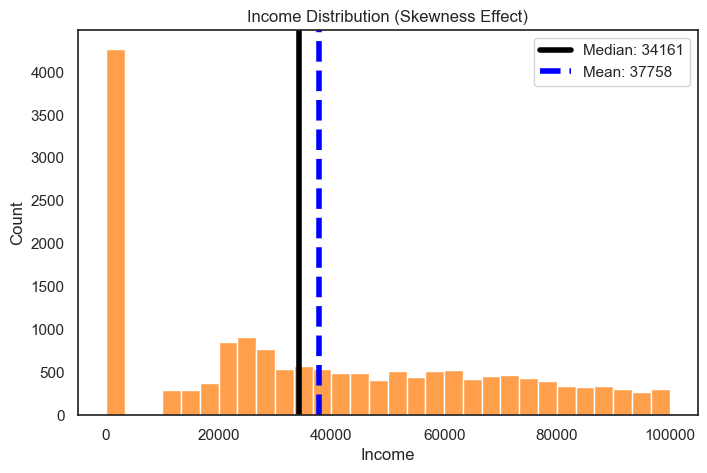

In [64]:
feature = subset_customers['Income']

mean_val = feature.mean()
median_val = feature.median()

sns.set_theme(style="white")

plt.figure(figsize=(8,5))
sns.histplot(feature, bins=30, color='tab:orange')

plt.axvline(median_val, color='black', linewidth=4,
            label=f"Median: {int(median_val)}")
plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=4,
            label=f"Mean: {int(mean_val)}")

plt.legend()
plt.title("Income Distribution (Skewness Effect)")
plt.show()

- Right‑skew: mean (≈ 37,753) > median (≈ 34,161) → long tail to high incomes.
- A huge spike at 0 → many records with income = 0 (likely “unknown / missing / unemployed / student”).
- we decided to use median as it less sensitive to the long tail 

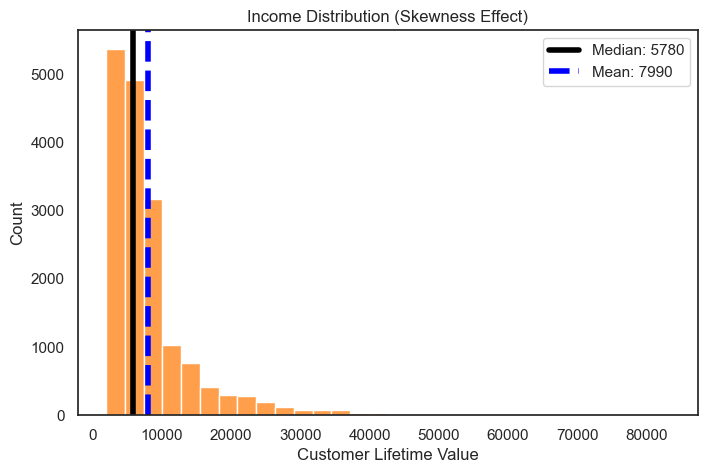

In [65]:
feature = subset_customers['Customer Lifetime Value']

mean_val = feature.mean()
median_val = feature.median()

sns.set_theme(style="white")

plt.figure(figsize=(8,5))
sns.histplot(feature, bins=30, color='tab:orange')

plt.axvline(median_val, color='black', linewidth=4,
            label=f"Median: {int(median_val)}")
plt.axvline(mean_val, color='blue', linestyle='dashed', linewidth=4,
            label=f"Mean: {int(mean_val)}")

plt.legend()
plt.title("Income Distribution (Skewness Effect)")
plt.show()

- A heavy right tail with a few very large CLVs (up to ~80k+)
- Right‑skewed distribution (mean > median).
- we decided to use median as it less sensitive to the long tail 




In [66]:
subset_customers = subset_customers.fillna({
    'Income': subset_customers['Income'].median(),
    'Customer Lifetime Value': subset_customers['Customer Lifetime Value'].median()
})

In [67]:
subset_customers.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
Location Code              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

In [68]:
subset_customers.count()

Loyalty#                   16921
Province or State          16921
City                       16921
Latitude                   16921
Longitude                  16921
Gender                     16921
Education                  16921
Income                     16921
Marital Status             16921
LoyaltyStatus              16921
Location Code              16921
EnrollmentDateOpening      16921
CancellationDate           16921
Customer Lifetime Value    16921
EnrollmentType             16921
dtype: int64

In [69]:
#we are creating a subset which only have peaople who have cancelled so that we can see if there is any significant differences in the distrubution 

In [70]:
subset_non_active = subset_customers[subset_customers["CancellationDate"] != '1900-01-01'].copy()

In [71]:
subset_non_active.shape

(2308, 15)

In [72]:
subset_non_active.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
Location Code              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
dtype: int64

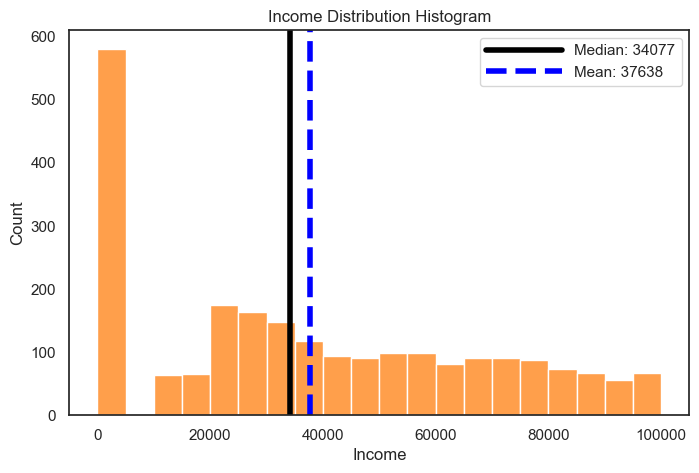

In [73]:
skew_demo = subset_non_active["Income"]

skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=20,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Income Distribution Histogram")
plt.show()


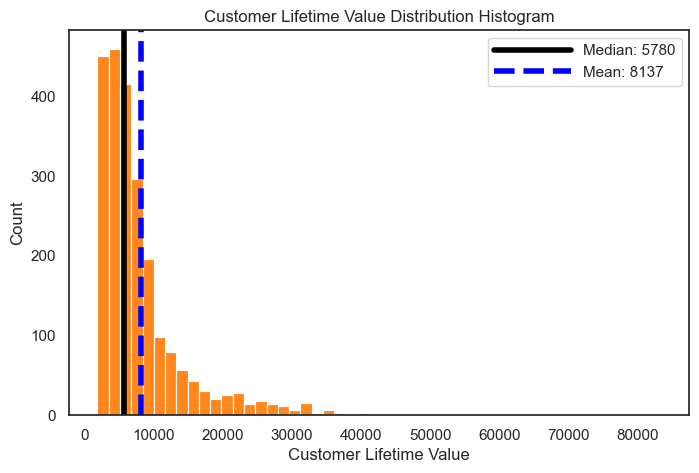

In [74]:
skew_demo = subset_non_active["Customer Lifetime Value"]

skew_demo = (
    skew_demo.astype(str)
             .str.replace(r"[,$]", "", regex=True)
             .replace(["", "nan", "None"], np.nan)
)
skew_demo = pd.to_numeric(skew_demo, errors="coerce").dropna()

skew_md = np.median(skew_demo)
skew_mn = np.mean(skew_demo)

sns.set_theme(style="white", palette=None)

fig, ax = plt.subplots(figsize=(8,5))

sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')
sns.histplot(skew_demo, bins=50,
             ax=ax, color='tab:orange')

ax.axvline(skew_md, color='black', linewidth=4,
           label='Median: {}'.format(int(skew_md)))
ax.axvline(skew_mn, color='blue', linestyle='dashed', linewidth=4,
           label='Mean: {}'.format(int(skew_mn)))

ax.legend(handlelength=5)

ax.set_title("Customer Lifetime Value Distribution Histogram")
plt.show()

sns.set()


#### Handling outliers :

In [75]:
subset_customers.select_dtypes(include='number').columns

Index(['Loyalty#', 'Latitude', 'Longitude', 'Income',
       'Customer Lifetime Value'],
      dtype='object')

In [76]:
#creating boxplots for all numeric variables in the subset_customers dataset to visually inspect their distributions and detect possible outliers.

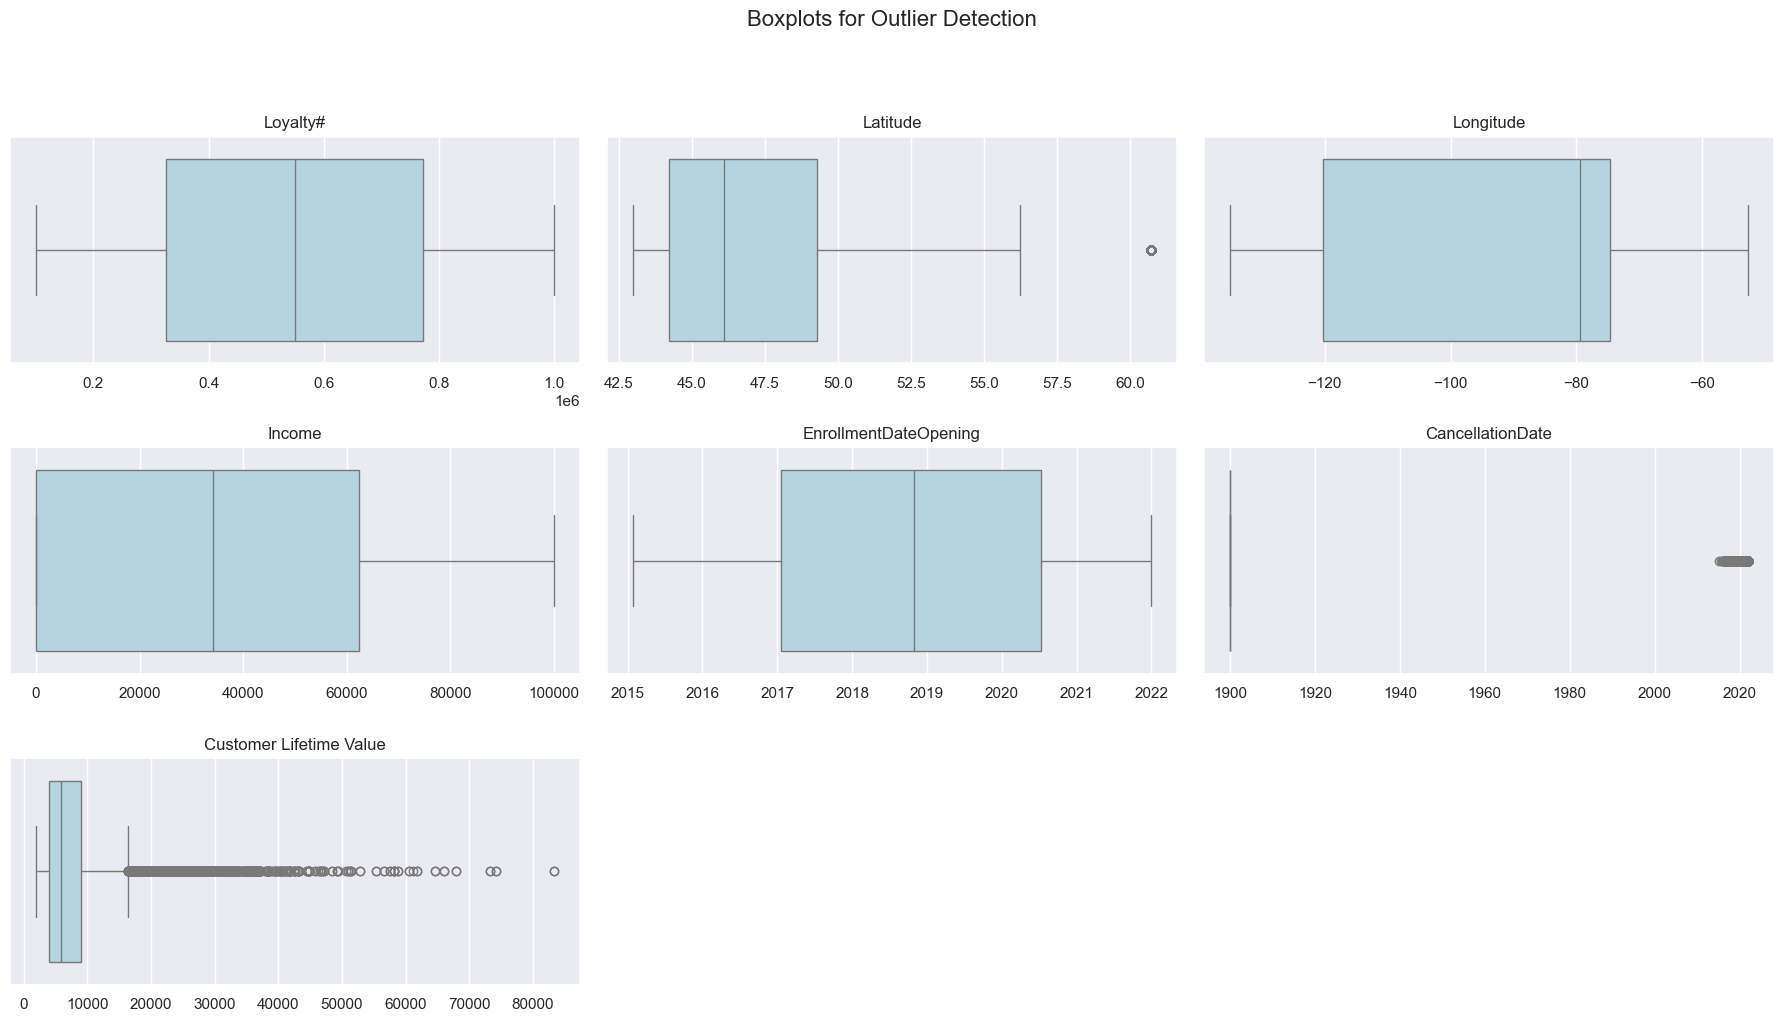

In [77]:
plt.figure(figsize=(18, 10))
plt.suptitle("Boxplots for Outlier Detection", fontsize=16, y=1.02)

for i, col in enumerate(Customers_metric_features , 1):
    plt.subplot(ceil(len(Customers_metric_features ) / 3), 3, i)
    sns.boxplot(x=subset_customers[col], color='lightblue')
    plt.title(col)
    plt.xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



- **Latitude & Longitude**  
  Mostly consistent values, but Longitude shows a slight outlier on the right side.

- **Income**  
  Wide range of values with some potential outliers on the higher end.  
  Indicates variability in customer income.

- **EnrollmentDateOpening**  
  Dates are concentrated between 2015 and 2021.  
  No significant outliers detected.

- **CancellationDate**  
  Most values are missing or concentrated around a single point (likely representing customers who have not canceled yet).

- **Customer Lifetime Value**  
  Highly skewed distribution with many extreme outliers on the higher end.  
  Suggests a few customers have very large lifetime values compared to the majority.


We chose this manual filtering method because the boxplot of Customer Lifetime Value (CLV) showed clear extreme outliers.
A manual threshold of CLV ≤ 60,000 was applied to remove unrealistic values while keeping most valid observations

In [78]:
filters_man = (
    (subset_customers['Customer Lifetime Value'] <= 60000) 
)

subset_cleaned_manual = subset_customers[filters_man]

# check percentage of data kept
print(
    'Percentage of data kept after removing outliers:',
    100 * np.round(subset_cleaned_manual.shape[0] / subset_customers.shape[0], 4)
)

Percentage of data kept after removing outliers: 99.9


In [79]:
#now we are checking the outliers in the flights dataset:

In [80]:
flights.select_dtypes(include='number').columns


Index(['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed'],
      dtype='object')

In [81]:
#creating boxplots for all numeric variables in the Flights dataset to visually inspect their distributions and detect possible outliers.

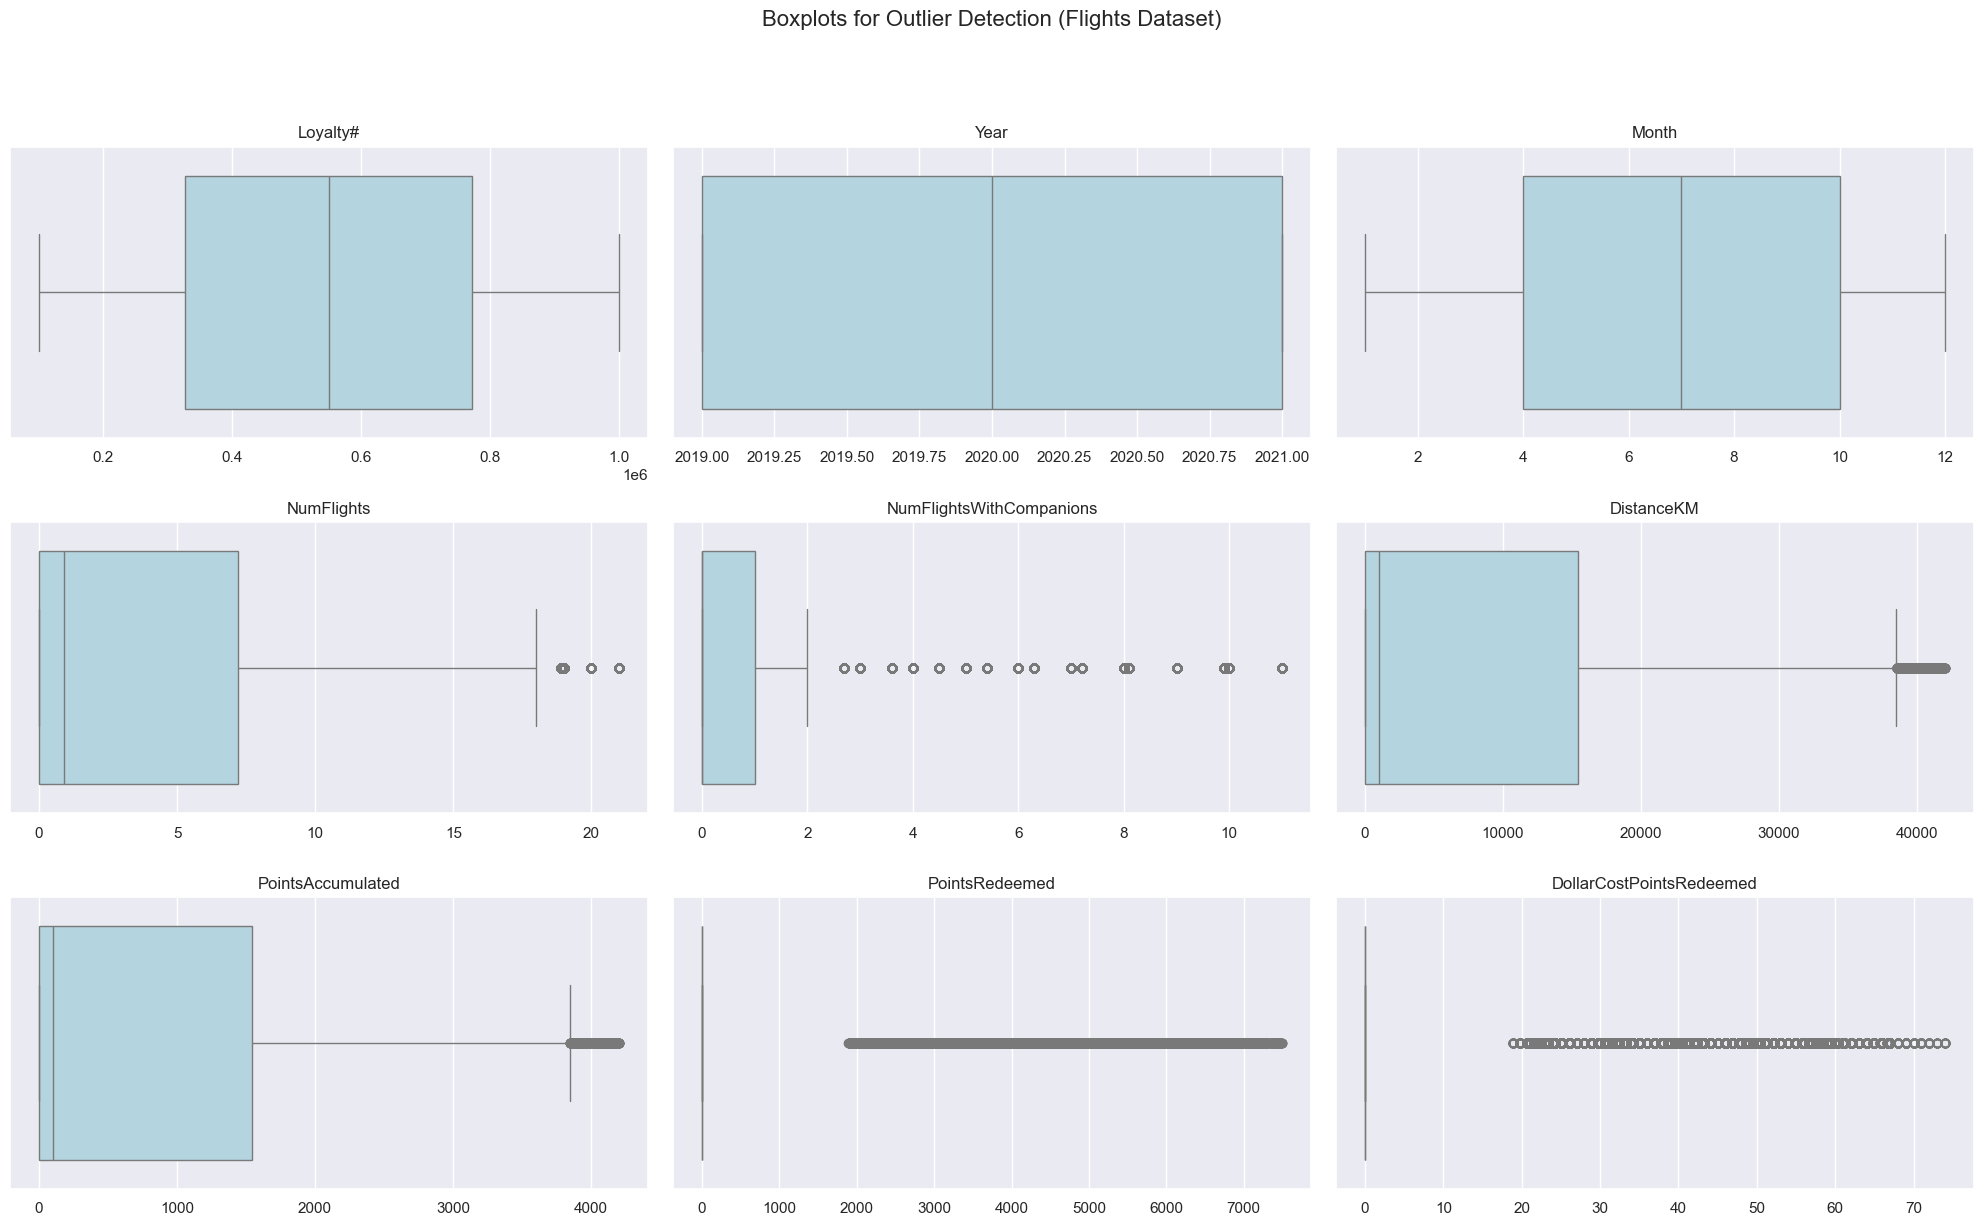

In [82]:
num_cols = ['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
            'DistanceKM', 'PointsAccumulated', 'PointsRedeemed', 'DollarCostPointsRedeemed']

plt.figure(figsize=(20, 12))
plt.suptitle("Boxplots for Outlier Detection (Flights Dataset)", fontsize=16, y=1.02)

for i, col in enumerate(num_cols, 1):
    plt.subplot(ceil(len(num_cols) / 3), 3, i)
    sns.boxplot(x=flights[col], color='lightblue')
    plt.title(col)
    plt.xlabel("")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


- **Loyalty#**  
  Distribution appears balanced with no significant outliers.

- **Year**  
  Values are concentrated between 2019 and 2021, as expected.  
  No major outliers detected.

- **Month**  
  Spread across 1–12 months with a uniform distribution.  
  No noticeable outliers.

- **NumFlights**  
  Most customers have fewer than 10 flights, but there are a few outliers above 15–20 flights.

- **NumFlightsWithCompanions**  
  Highly skewed with many zeros and several outliers above 5 flights with companions.

- **DistanceKM**  
  Majority of values are below 20,000 km, but there are extreme outliers reaching up to 40,000 km.

- **PointsAccumulated**  
  Most values are concentrated at lower ranges, but there are outliers above 4,000 points.

- **PointsRedeemed**  
  Distribution is skewed with several outliers above 7,000 points.

- **DollarCostPointsRedeemed**  
  Mostly concentrated at lower values, but there are many outliers above 50 units.


In [83]:
#The plots show that variables such as Number of Flights, DistanceKM, and Points Accumulated have several extreme values, while others like Year and Month appear well distributed.

In [84]:
perc_above_8 = (
    (flights["NumFlightsWithCompanions"] > 8).sum() / len(flights)
) * 100

print(f"Percentage of records with NumFlightsWithCompanions > 8: {perc_above_8:.2f}%")

Percentage of records with NumFlightsWithCompanions > 8: 1.08%


In [85]:
flights.count()

Loyalty#                    605533
Year                        605533
Month                       605533
YearMonthDate               605533
NumFlights                  605533
NumFlightsWithCompanions    605533
DistanceKM                  605533
PointsAccumulated           605533
PointsRedeemed              605533
DollarCostPointsRedeemed    605533
dtype: int64

In [86]:
#Apply IQR method to detect and keep reasonable values

In [87]:
df_original = flights

col = "NumFlightsWithCompanions"
s = df_original[col].dropna()

q1, q3 = s.quantile([0.25, 0.75])
iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
mask_iqr = df_original[col].between(lo, hi, inclusive="both")

mask_manual = df_original[col] <= 8

keep_mask = mask_iqr | mask_manual
df_out = df_original[keep_mask]

print(
    "Percentage of data kept after filtering:",
    np.round(df_out.shape[0] / df_original.shape[0] * 100, 2), "%"
)

Percentage of data kept after filtering: 98.92 %


In [88]:
# Use IQR to filter NumFlights

In [89]:

df = flights
metric_features = ["NumFlights"]

# Compute the IQR
q1 = df[metric_features].quantile(.25)

# Calculate Q3
q3 = df[metric_features].quantile(.75)

# Calculate IQR
iqr = (q3 - q1)

# Compute upper and lower limits
lower_lim = q1 - (1.5 * iqr)
upper_lim = q3 + (1.5 * iqr)

filters_iqr = []
for metric in metric_features:
    llim = lower_lim[metric]
    ulim = upper_lim[metric]
    filters_iqr.append(df[metric].between(llim, ulim, inclusive='neither'))

filters_iqr_all = pd.Series(np.all(filters_iqr, 0), index=df.index)

# Apply filter
df_iqr_clean = df[filters_iqr_all]

print('Percentage of data kept after IQR filtering:',
      100 * np.round(df_iqr_clean.shape[0] / df.shape[0], 4))


Percentage of data kept after IQR filtering: 98.86


In [90]:
flights.count()

Loyalty#                    605533
Year                        605533
Month                       605533
YearMonthDate               605533
NumFlights                  605533
NumFlightsWithCompanions    605533
DistanceKM                  605533
PointsAccumulated           605533
PointsRedeemed              605533
DollarCostPointsRedeemed    605533
dtype: int64

We did not use the interquartile range for points redeemed, points accumulated, or dollar cost points redeemed, as these variables were heavily right-skewed, with most individuals not redeeming or accumulating points. However, examining those who did redeem or accumulate points provides insights into behaviour, price sensitivity across segments, and opportunities for improvement. 

# 3.Deep Analysis and Feature Engineering

In [91]:
#This visualization identifies how many unique customers traveled from each city

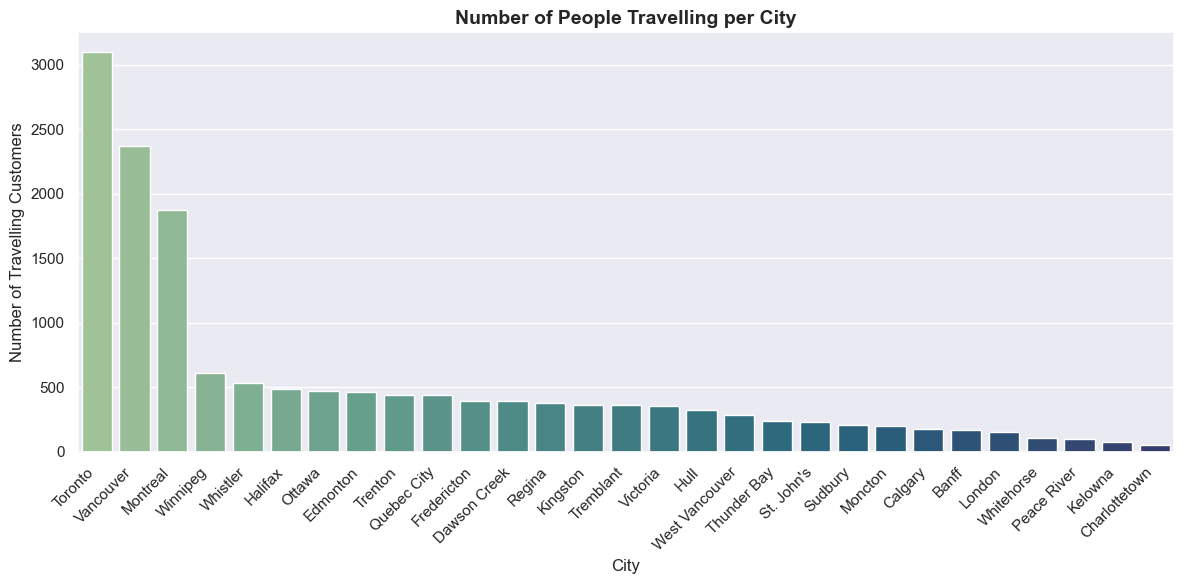

In [92]:

flown_customers = flights[flights["DistanceKM"] > 0]["Loyalty#"].unique()

travelling_customers = subset_customers[subset_customers["Loyalty#"].isin(flown_customers)]

travellers_per_city = (
    travelling_customers.groupby("City")["Loyalty#"]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="NumTravellers")
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=travellers_per_city,
    x="City", y="NumTravellers",
    palette="crest"
)

plt.title("Number of People Travelling per City", fontsize=14, weight="bold")
plt.xlabel("City")
plt.ylabel("Number of Travelling Customers")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


- Toronto has the largest number of traveling customers, followed by Vancouver and Montreal.
- This insight suggests that marketing or loyalty strategies could focus on these high-volume cities.


#### New Feature (is_active ):

This feature indicates whether a customer is active or canceled.
Rule:
If CancellationDate equals 1900-01-01, the customer is considered active (is_active = 1).
Otherwise, the customer is considered canceled (is_active = 0).

In [93]:

subset_customers['CancellationDate'] = pd.to_datetime(
    subset_customers['CancellationDate'], errors='coerce'
)

SENTINEL = pd.Timestamp('1900-01-01')

subset_customers['is_active'] = (subset_customers['CancellationDate'] == SENTINEL).astype(int)

print(subset_customers[['CancellationDate', 'is_active']].head(10))
print(subset_customers['is_active'].value_counts())


  CancellationDate  is_active
0       1900-01-01          1
1       1900-01-01          1
2       2021-01-08          0
3       1900-01-01          1
4       1900-01-01          1
5       1900-01-01          1
6       1900-01-01          1
7       1900-01-01          1
8       1900-01-01          1
9       1900-01-01          1
is_active
1    14613
0     2308
Name: count, dtype: int64


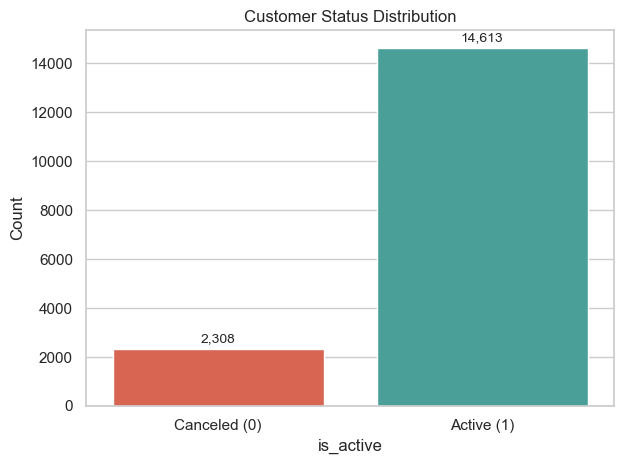

In [94]:

sns.set_theme(style="whitegrid")

ax = sns.countplot(x=subset_customers['is_active'], palette=['#ED553B','#3CAEA3'])
ax.set_xticklabels(['Canceled (0)', 'Active (1)'])
ax.set_title("Customer Status Distribution")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0,3), textcoords='offset points')
plt.tight_layout()
plt.show()


In [95]:
subset_customers.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
Location Code              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
is_active                  0
dtype: int64

#### New Feature (HasFlown):

Here in order to evaluate customer travel activity by ensuring flight distance data is accurate and consistent,
identifying how many flights represent real travel versus inactivity.

In [96]:
flights["DistanceKM"] = pd.to_numeric(flights["DistanceKM"], errors="coerce")
print(flights["DistanceKM"].dtype)
print(flights["DistanceKM"].describe())

float64
count    605533.000000
mean       7977.403603
std       10270.215544
min           0.000000
25%           0.000000
50%         993.600000
75%       15408.900000
max       42040.000000
Name: DistanceKM, dtype: float64


In [97]:
# Count and percentage of zeros in DistanceKM
zero_count = (flights["DistanceKM"] == 0).sum()
zero_pct = (flights["DistanceKM"] == 0).mean() * 100

print(f"Number of zeros in DistanceKM: {zero_count}")
print(f"Percentage of zeros: {zero_pct:.2f}%")


Number of zeros in DistanceKM: 295720
Percentage of zeros: 48.84%


Nearly half of all flights record (48.84%) show a distance of 0 km, meaning many customers had months without any travel activity.

In [98]:
# creating new feature to indicate whether a flight record represents actual travel activity:

In [99]:
flights["HasFlown"] = (flights["DistanceKM"] > 0).astype(int)
print(flights["HasFlown"].value_counts())
print(flights['HasFlown'].head(10))

HasFlown
1    309813
0    295720
Name: count, dtype: int64
0    1
1    0
2    1
3    1
4    1
5    1
6    1
7    1
8    1
9    0
Name: HasFlown, dtype: int64


In [100]:
flights.head(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,HasFlown
0,413052,2021,12,2021-12-01,2.0,2.0,9384.0,938.0,0.0,0.0,1
1,464105,2021,12,2021-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0
2,681785,2021,12,2021-12-01,10.0,3.0,14745.0,1474.0,0.0,0.0,1
3,185013,2021,12,2021-12-01,16.0,4.0,26311.0,2631.0,3213.0,32.0,1
4,216596,2021,12,2021-12-01,9.0,0.0,19275.0,1927.0,0.0,0.0,1
5,486956,2021,12,2021-12-01,12.0,7.0,23967.0,2396.0,0.0,0.0,1
6,247514,2021,12,2021-12-01,17.0,7.0,23029.0,2302.0,0.0,0.0,1
7,711864,2021,12,2021-12-01,6.0,0.0,25995.0,2599.0,0.0,0.0,1
8,721372,2021,12,2021-12-01,11.0,3.0,30758.0,3075.0,0.0,0.0,1
9,762715,2021,12,2021-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0


In [101]:
#Created a box plot to visualize the DistanceKM for these active customer per year/month
# HasFlown = 1 if DistanceKM > 0 (real travel)

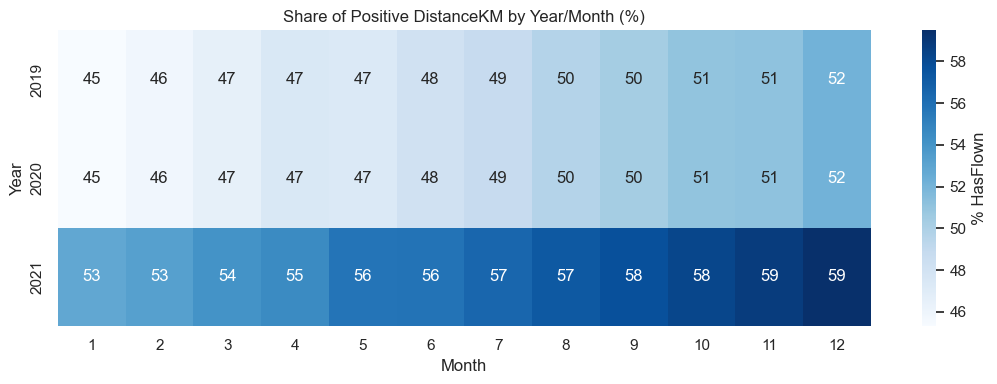

In [102]:
has_flown_rate = (flights.assign(HasFlown = flights["DistanceKM"].gt(0).astype(int))
                  .groupby(["Year","Month"])["HasFlown"]
                  .mean().unstack("Month"))

plt.figure(figsize=(11,4))
ax = sns.heatmap(100 * has_flown_rate, cmap="Blues", annot=True, fmt=".0f", cbar_kws={"label":"% HasFlown"})
ax.set_title("Share of Positive DistanceKM by Year/Month (%)")
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.show()


- **2019 and 2020:**  
  Fairly stable, around **45–52%** across months.  
  Indicates that roughly half of the records in those years represent actual flights.

- **2021:**  
  Noticeable increase: **53–59%** across months.  
  Suggests higher engagement or better data completeness in 2021 compared to previous years.

- **Seasonality:**  
  Slight upward trend toward the end of each year (**Nov–Dec**), but overall variation is small.


In [103]:
#Distribution of real distances (non‑zero only)
# Only positive distances to study actual travel

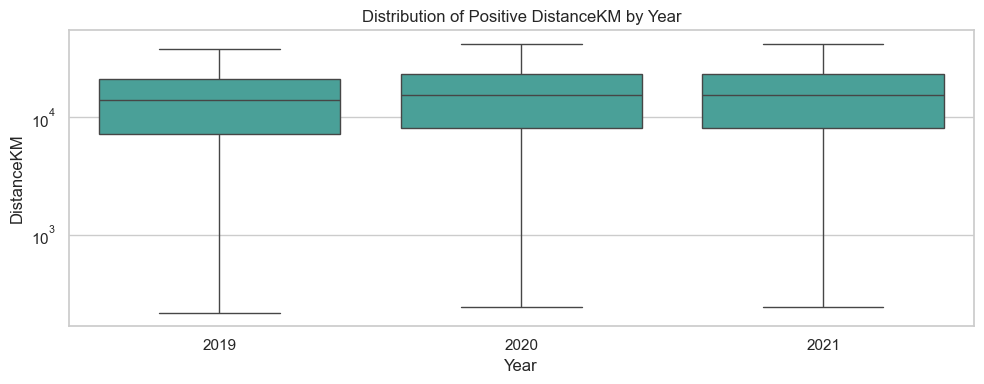

In [104]:

pos = flights[flights["DistanceKM"] > 0].copy()

plt.figure(figsize=(10,4))
ax = sns.boxplot(data=pos, x="Year", y="DistanceKM", color="#3CAEA3")
ax.set_title("Distribution of Positive DistanceKM by Year")
ax.set_xlabel("Year")
ax.set_ylabel("DistanceKM")
ax.set_yscale("log")  
plt.tight_layout()
plt.show()


In [105]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
dtype: int64

#### New Feature (HasRedeemedPoints) :

In [106]:
zero_pct = (flights["PointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 points redeemed: 94.16%


In [107]:
flights["HasRedeemedPoints"] = (flights["PointsRedeemed"] > 0).astype(int)

flights["HasRedeemedPoints"].value_counts(normalize=True) * 100

HasRedeemedPoints
0    94.155067
1     5.844933
Name: proportion, dtype: float64

In [108]:
zero_pct = (flights["DollarCostPointsRedeemed"] == 0).mean() * 100
print(f"Percentage of customers with 0 dollar cost points redeemed: {zero_pct:.2f}%")


Percentage of customers with 0 dollar cost points redeemed: 94.16%


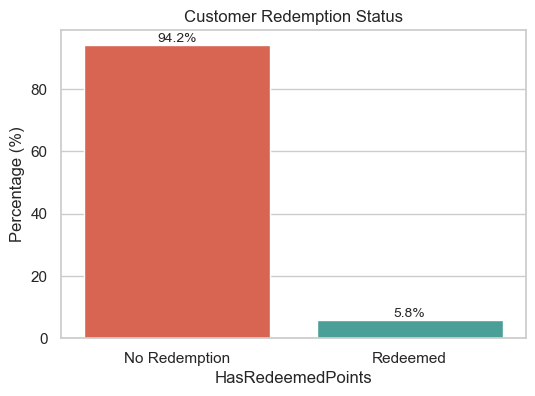

In [109]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,4))
ax = sns.barplot(
    x=flights["HasRedeemedPoints"].value_counts().index,
    y=flights["HasRedeemedPoints"].value_counts(normalize=True)*100,
    palette=["#ED553B","#3CAEA3"]
)
ax.set_xticklabels(["No Redemption","Redeemed"])
ax.set_ylabel("Percentage (%)")
ax.set_title("Customer Redemption Status")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.show()


- About **94% of customers have not redeemed any points**, and only ~6% have redeemed at least once.  
- Similarly, **94% have not redeemed dollar-cost points**.  
- This indicates that the redemption feature is rarely used, suggesting low engagement with the loyalty program and an opportunity to improve awareness or incentives for redemption.


In [110]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
dtype: int64

In [111]:
flights.head(10)

,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,HasFlown,HasRedeemedPoints
0,413052,2021,12,2021-12-01,2.0,2.0,9384.0,938.0,0.0,0.0,1,0
1,464105,2021,12,2021-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,681785,2021,12,2021-12-01,10.0,3.0,14745.0,1474.0,0.0,0.0,1,0
3,185013,2021,12,2021-12-01,16.0,4.0,26311.0,2631.0,3213.0,32.0,1,1
4,216596,2021,12,2021-12-01,9.0,0.0,19275.0,1927.0,0.0,0.0,1,0
5,486956,2021,12,2021-12-01,12.0,7.0,23967.0,2396.0,0.0,0.0,1,0
6,247514,2021,12,2021-12-01,17.0,7.0,23029.0,2302.0,0.0,0.0,1,0
7,711864,2021,12,2021-12-01,6.0,0.0,25995.0,2599.0,0.0,0.0,1,0
8,721372,2021,12,2021-12-01,11.0,3.0,30758.0,3075.0,0.0,0.0,1,0
9,762715,2021,12,2021-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0,0


#### New Feature (RedeemRate) :

RedeemRate adds depth to behavioral analysis by showing redemption intensity, while HasRedeemedPoints remains useful for simple flags and interpretability.

In [112]:
flights['RedeemRate'] = (
    flights['PointsRedeemed'].fillna(0) /
    flights['PointsAccumulated'].replace({0: np.nan})  
).replace([np.inf, -np.inf], np.nan) \
 .fillna(0) \
 .clip(0, 1)

In [113]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
RedeemRate                  0
dtype: int64

#### New Feature (AverageDistancePerFlight) :

Create a new feature (AverageDistancePerFlight) representing the average distance traveled per flight by each customer. 
This helps identify customers who take short vs. long trips.

In [114]:

flights['NumFlights']  = pd.to_numeric(flights['NumFlights'],  errors='coerce')
flights['DistanceKM']  = pd.to_numeric(flights['DistanceKM'], errors='coerce')

flights['avg_distance_per_flight'] = flights['DistanceKM'].div(
    flights['NumFlights'].replace(0, np.nan)
).fillna(0)


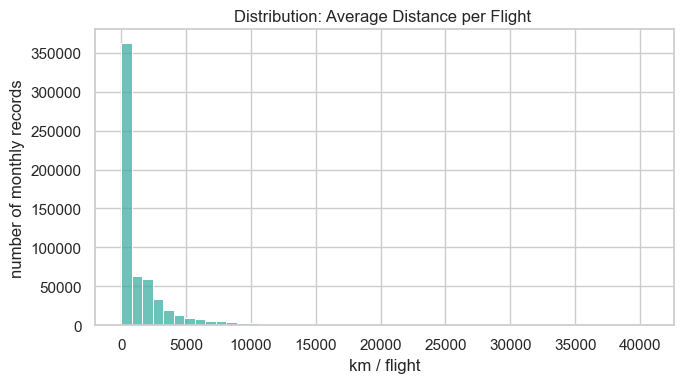

In [115]:


sns.set_theme(style="whitegrid")
plt.figure(figsize=(7,4))
sns.histplot(flights['avg_distance_per_flight'], bins=50, color="#3CAEA3")
plt.title("Distribution: Average Distance per Flight ")
plt.xlabel("km / flight"); plt.ylabel("number of monthly records")
plt.tight_layout(); plt.show()



- Each bar shows how many monthly records fall into a specific range of **Average Distance per Flight** (km per flight).
- The very tall bar near zero indicates that **most months had short flights**, typically less than **1,000 km per flight**.
- Bars that appear far to the right, even if small, represent **rare months with very long flights** (long-haul journeys).


In [116]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
RedeemRate                  0
avg_distance_per_flight     0
dtype: int64

In [117]:
flights.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
HasFlown                    0
HasRedeemedPoints           0
RedeemRate                  0
avg_distance_per_flight     0
dtype: int64

#### New Feature (income_category) :

In [118]:
subset_customers['income_category'] = pd.cut(subset_customers['Income'], bins=[-1,0, 30000, 60000, 100000], labels=['No Income','Low', 'Medium', 'High'])

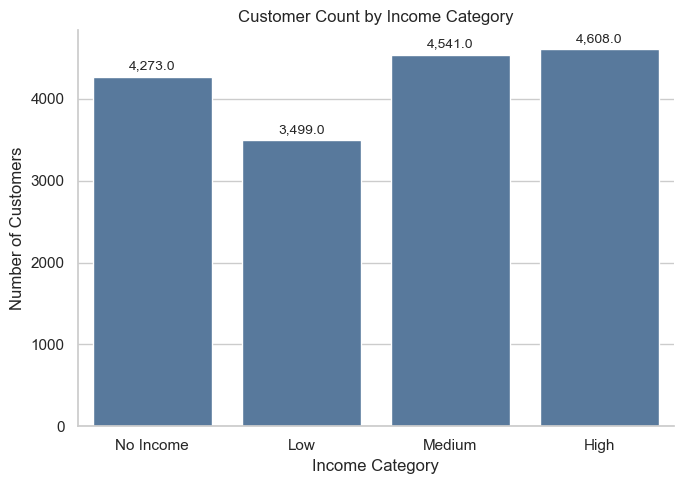

In [119]:
order = ['No Income','Low', 'Medium', 'High']

plt.figure(figsize=(7, 5))
ax = sns.countplot(
    data=subset_customers,
    x='income_category',
    order=order,
    color='#4C78A8'
)
ax.set_title('Customer Count by Income Category')
ax.set_xlabel('Income Category')
ax.set_ylabel('Number of Customers')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:,}', (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()


- **The majority of customers fall into the Medium and High income categories**, indicating that the customer base tends to have moderate to high purchasing power.
- **The Low income group is significantly smaller**, which could influence marketing strategies, product pricing, and targeted promotions.
- The **No Income group being large** might represent customers with missing income data or those genuinely without income (students, dependents).

In [120]:
subset_customers.isna().sum()

Loyalty#                   0
Province or State          0
City                       0
Latitude                   0
Longitude                  0
Gender                     0
Education                  0
Income                     0
Marital Status             0
LoyaltyStatus              0
Location Code              0
EnrollmentDateOpening      0
CancellationDate           0
Customer Lifetime Value    0
EnrollmentType             0
is_active                  0
income_category            0
dtype: int64

#### New Feature (tenure_days) :

This Feature clarify the number of days a customer has been enrolled in the loyalty program.
Calculated as:last_date (2021-12-31) - EnrollmentDateOpening

In [121]:

last_date = pd.Timestamp('2021-12-31')  # last date in dataset
subset_customers['tenure_days'] = (last_date - subset_customers['EnrollmentDateOpening']).dt.days


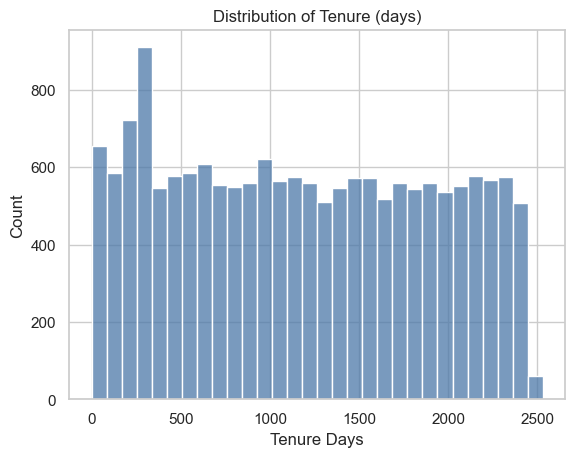

In [122]:
sns.histplot(subset_customers['tenure_days'], bins=30, color='#4C78A8')
plt.title("Distribution of Tenure (days)")
plt.xlabel("Tenure Days")
plt.ylabel("Count")
plt.show()


#### New Feature (is_zero_income) :

This Feature indicates customers with no reported income (could be missing or special case).

In [123]:
subset_customers['Income'] = pd.to_numeric(subset_customers['Income'], errors='coerce')
subset_customers['is_zero_income'] = (subset_customers['Income'] == 0).astype(int)

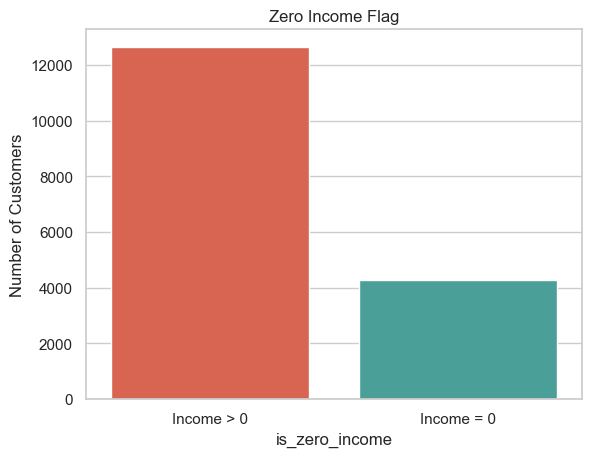

In [124]:

sns.countplot(x=subset_customers['is_zero_income'], palette=['#ED553B','#3CAEA3'])
plt.xticks([0,1], ['Income > 0', 'Income = 0'])
plt.title("Zero Income Flag")
plt.ylabel("Number of Customers")
plt.show()


In [125]:
subset_customers.head(10)

,Loyalty#,Province or State,City,Latitude,Longitude,Gender,Education,Income,Marital Status,LoyaltyStatus,Location Code,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType,is_active,income_category,tenure_days,is_zero_income
0,480934,Ontario,Toronto,43.653225,-79.383186,female,Bachelor,70146.0,Married,Star,Urban,2019-02-15,1900-01-01,3839.14,Standard,1,High,1050,0
1,549612,Alberta,Edmonton,53.544388,-113.490930,male,College,0.0,Divorced,Star,Rural,2019-03-09,1900-01-01,3839.61,Standard,1,No Income,1028,1
2,429460,British Columbia,Vancouver,49.282730,-123.120740,male,College,0.0,Single,Star,Urban,2017-07-14,2021-01-08,3839.75,Standard,0,No Income,1631,1
3,608370,Ontario,Toronto,43.653225,-79.383186,male,College,0.0,Single,Star,Suburban,2016-02-17,1900-01-01,3839.75,Standard,1,No Income,2144,1
4,530508,Quebec,Hull,45.428730,-75.713364,male,Bachelor,97832.0,Married,Star,Suburban,2017-10-25,1900-01-01,3842.79,2021 Promotion,1,High,1528,0
5,193662,Yukon,Whitehorse,60.721188,-135.056840,male,Bachelor,26262.0,Married,Star,Rural,2015-05-07,1900-01-01,3844.57,Standard,1,Low,2430,0
6,927943,Ontario,Toronto,43.653225,-79.383186,female,College,0.0,Single,Star,Urban,2017-06-09,1900-01-01,3857.95,Standard,1,No Income,1666,1
7,188893,Ontario,Trenton,44.101128,-77.576309,male,Bachelor,93272.0,Married,Star,Suburban,2019-12-08,1900-01-01,3861.49,Standard,1,High,754,0
8,852392,Quebec,Montreal,45.501690,-73.567253,female,Bachelor,93272.0,Married,Star,Suburban,2018-05-30,1900-01-01,3861.49,Standard,1,High,1311,0
9,866307,Ontario,Toronto,43.653225,-79.383186,male,Bachelor,93272.0,Married,Star,Suburban,2019-10-14,1900-01-01,3861.49,Standard,1,High,809,0


In [126]:
print(flights.shape)
flights.head(10)

(605533, 14)


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,HasFlown,HasRedeemedPoints,RedeemRate,avg_distance_per_flight
0,413052,2021,12,2021-12-01,2.0,2.0,9384.0,938.0,0.0,0.0,1,0,0.0,4692.000000
1,464105,2021,12,2021-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.000000
2,681785,2021,12,2021-12-01,10.0,3.0,14745.0,1474.0,0.0,0.0,1,0,0.0,1474.500000
3,185013,2021,12,2021-12-01,16.0,4.0,26311.0,2631.0,3213.0,32.0,1,1,1.0,1644.437500
4,216596,2021,12,2021-12-01,9.0,0.0,19275.0,1927.0,0.0,0.0,1,0,0.0,2141.666667
5,486956,2021,12,2021-12-01,12.0,7.0,23967.0,2396.0,0.0,0.0,1,0,0.0,1997.250000
6,247514,2021,12,2021-12-01,17.0,7.0,23029.0,2302.0,0.0,0.0,1,0,0.0,1354.647059
7,711864,2021,12,2021-12-01,6.0,0.0,25995.0,2599.0,0.0,0.0,1,0,0.0,4332.500000
8,721372,2021,12,2021-12-01,11.0,3.0,30758.0,3075.0,0.0,0.0,1,0,0.0,2796.181818
9,762715,2021,12,2021-12-01,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.000000


### Merging the two datasets in one dataset :

The flight dataset contains multiple rows per customer showing his activity , with one record per month. To simplify analysis, we aggregate this data so that each customer has a single summarized record. 
Performing this aggregation before merging with customer_subset ensures cleaner and more efficient processing.
The aggregation is grouped by Loyalty and produces new columns as follows:
Group by Loyalty and compute:

Sums: total flights, total companion flights, total distance traveled, total points accumulated, total points redeemed, and total dollar cost of redeemed points.
Time-based stats: number of distinct periods (months), first active period, and last active period.
Flags: HasFlown_any and HasRedeemed_any using max (any occurrence → 1, else 0).
Averages: RedeemRate_mean (simple mean across all periods).

In [127]:

for col in ['NumFlights','NumFlightsWithCompanions','DistanceKM',
            'PointsAccumulated','PointsRedeemed','DollarCostPointsRedeemed']:
    flights[col] = pd.to_numeric(flights[col], errors='coerce')

flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], errors='coerce')

agg = (flights
       .groupby('Loyalty#', as_index=False)
       .agg(
           NumFlights_total=('NumFlights', 'sum'),
           NumFlightsWithCompanions_total=('NumFlightsWithCompanions', 'sum'),
           DistanceKM_total=('DistanceKM', 'sum'),
           PointsAccumulated_total=('PointsAccumulated', 'sum'),
           PointsRedeemed_total=('PointsRedeemed', 'sum'),
           DollarCostPointsRedeemed_total=('DollarCostPointsRedeemed', 'sum'),
           periods_nunique=('YearMonthDate', 'nunique'),
           first_period=('YearMonthDate', 'min'),
           last_period=('YearMonthDate', 'max'),
           HasFlown_any=('HasFlown', 'max'),
           HasRedeemed_any=('HasRedeemedPoints', 'max'),
           RedeemRate_mean=('RedeemRate', 'mean'),
       )
)

agg['avg_distance_per_flight'] = np.where(
    agg['NumFlights_total'] > 0,
    agg['DistanceKM_total'] / agg['NumFlights_total'],
    np.nan
)


agg['RedeemRate_weighted'] = np.where(
    agg['PointsAccumulated_total'] > 0,
    agg['PointsRedeemed_total'] / agg['PointsAccumulated_total'],
    np.nan
)

agg['last_year'] = agg['last_period'].dt.year
agg['last_month'] = agg['last_period'].dt.month

agg.head(10)


,Loyalty#,NumFlights_total,NumFlightsWithCompanions_total,DistanceKM_total,PointsAccumulated_total,PointsRedeemed_total,DollarCostPointsRedeemed_total,periods_nunique,first_period,last_period,HasFlown_any,HasRedeemed_any,RedeemRate_mean,avg_distance_per_flight,RedeemRate_weighted,last_year,last_month
0,100018,229.9,49.4,530230.0,53014.30,20562.8,201.9,36,2019-01-01,2021-12-01,1,1,0.138889,2306.350587,0.387873,2021,12
1,100102,247.7,58.2,339114.6,33903.96,18760.6,186.2,36,2019-01-01,2021-12-01,1,1,0.111111,1369.053694,0.553345,2021,12
2,100140,216.8,54.2,432030.8,43192.58,4896.0,48.0,36,2019-01-01,2021-12-01,1,1,0.027778,1992.761993,0.113353,2021,12
3,100214,112.3,19.7,364601.7,36453.77,12908.6,127.3,36,2019-01-01,2021-12-01,1,1,0.111111,3246.675868,0.354109,2021,12
4,100272,186.4,53.1,429630.5,42953.25,10891.4,107.0,36,2019-01-01,2021-12-01,1,1,0.083333,2304.884657,0.253564,2021,12
5,100301,238.6,69.4,456142.3,45605.63,11013.0,109.0,36,2019-01-01,2021-12-01,1,1,0.083333,1911.744761,0.241483,2021,12
6,100364,174.9,44.2,343383.5,34332.25,8707.7,85.5,36,2019-01-01,2021-12-01,1,1,0.055556,1963.313322,0.253630,2021,12
7,100380,169.1,63.7,367306.4,36723.94,17829.6,174.8,36,2019-01-01,2021-12-01,1,1,0.111111,2172.125370,0.485503,2021,12
8,100428,159.7,29.2,342343.2,34224.82,19927.1,197.0,36,2019-01-01,2021-12-01,1,1,0.109250,2143.664371,0.582241,2021,12
9,100504,106.6,9.6,152468.1,15242.21,0.0,0.0,36,2019-01-01,2021-12-01,1,0,0.000000,1430.282364,0.000000,2021,12


In [128]:
agg['Loyalty#'].duplicated().sum()

np.int64(0)

In [129]:
merged= subset_customers.merge(agg, on='Loyalty#', how='left')
print("Merged shape:", merged.shape)
print(merged.head())


Merged shape: (16921, 35)
   Loyalty# Province or State       City   Latitude   Longitude  Gender  \
0    480934           Ontario    Toronto  43.653225  -79.383186  female   
1    549612           Alberta   Edmonton  53.544388 -113.490930    male   
2    429460  British Columbia  Vancouver  49.282730 -123.120740    male   
3    608370           Ontario    Toronto  43.653225  -79.383186    male   
4    530508            Quebec       Hull  45.428730  -75.713364    male   

  Education   Income Marital Status LoyaltyStatus  ... periods_nunique  \
0  Bachelor  70146.0        Married          Star  ...            36.0   
1   College      0.0       Divorced          Star  ...            36.0   
2   College      0.0         Single          Star  ...            36.0   
3   College      0.0         Single          Star  ...            36.0   
4  Bachelor  97832.0        Married          Star  ...            36.0   

  first_period last_period  HasFlown_any HasRedeemed_any  RedeemRate_mean  \
0

In [130]:
merged.columns

Index(['Loyalty#', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'Location Code', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'is_active',
       'income_category', 'tenure_days', 'is_zero_income', 'NumFlights_total',
       'NumFlightsWithCompanions_total', 'DistanceKM_total',
       'PointsAccumulated_total', 'PointsRedeemed_total',
       'DollarCostPointsRedeemed_total', 'periods_nunique', 'first_period',
       'last_period', 'HasFlown_any', 'HasRedeemed_any', 'RedeemRate_mean',
       'avg_distance_per_flight', 'RedeemRate_weighted', 'last_year',
       'last_month'],
      dtype='object')

In [131]:
merged.isna().sum()

Loyalty#                             0
Province or State                    0
City                                 0
Latitude                             0
Longitude                            0
Gender                               0
Education                            0
Income                               0
Marital Status                       0
LoyaltyStatus                        0
Location Code                        0
EnrollmentDateOpening                0
CancellationDate                     0
Customer Lifetime Value              0
EnrollmentType                       0
is_active                            0
income_category                      0
tenure_days                          0
is_zero_income                       0
NumFlights_total                    20
NumFlightsWithCompanions_total      20
DistanceKM_total                    20
PointsAccumulated_total             20
PointsRedeemed_total                20
DollarCostPointsRedeemed_total      20
periods_nunique          

we are checking records that have missing values after merging and don't we that 20 customer don't have anyrecords in flights 

In [132]:
subset_customers['Loyalty#'] = subset_customers['Loyalty#'].astype(str).str.strip()
agg['Loyalty#'] = agg['Loyalty#'].astype(str).str.strip()

#we are checking records with missing values 
not_matched = subset_customers.loc[
    ~subset_customers['Loyalty#'].isin(agg['Loyalty#'])
, ['Loyalty#']].drop_duplicates()
print("Customers in subset_customers without agg rows:", not_matched.shape[0])
print(not_matched.head(20))



Customers in subset_customers without agg rows: 20
      Loyalty#
16901   999987
16902   999988
16903   999989
16904   999990
16905   999991
16906   999992
16907   999993
16908   999994
16909   999995
16910   999996
16911   999997
16912   999998
16913   999999
16914   100017
16915   100011
16916   100012
16917   100013
16918   100014
16919   100015
16920   100016


After checking , we found that those customers were enrolled and cancelled at the same day and record was found at the flight dataset 
and since they are only 20 , so we decided to delete them .

In [133]:
ids_to_remove = [
    999987, 999988, 999989, 999990, 999991,
    999992, 999993, 999994, 999995, 999996,
    999997, 999998, 999999, 100017, 100011,
    100012, 100013, 100014, 100015, 100016
]

merged['Loyalty#'] = merged['Loyalty#'].astype(int)

merged = merged[~merged['Loyalty#'].isin(ids_to_remove)].copy()

print("New shape after removing the 20 customers:", merged.shape)

New shape after removing the 20 customers: (16901, 35)


Reason for filling NaN with 0:
These columns (avg_distance_per_flight, RedeemRate_weighted) are ratios that become undefined when the customer has no flights or points.
We replaced NaN with 0 to indicate “no activity” for easier reporting and visualization.

In [134]:

merged[['avg_distance_per_flight','RedeemRate_weighted']] = \
    merged[['avg_distance_per_flight','RedeemRate_weighted']].fillna(0)


In [135]:
merged.isna().sum()

Loyalty#                          0
Province or State                 0
City                              0
Latitude                          0
Longitude                         0
Gender                            0
Education                         0
Income                            0
Marital Status                    0
LoyaltyStatus                     0
Location Code                     0
EnrollmentDateOpening             0
CancellationDate                  0
Customer Lifetime Value           0
EnrollmentType                    0
is_active                         0
income_category                   0
tenure_days                       0
is_zero_income                    0
NumFlights_total                  0
NumFlightsWithCompanions_total    0
DistanceKM_total                  0
PointsAccumulated_total           0
PointsRedeemed_total              0
DollarCostPointsRedeemed_total    0
periods_nunique                   0
first_period                      0
last_period                 

# 4. Feature Selection :

In [136]:
categorical_cols = merged.select_dtypes(exclude=["number"]).columns.tolist()
print("Categorical columns:", categorical_cols)


numerical_cols = merged.select_dtypes(include=["number"]).columns.tolist()
print("Numerical columns:", numerical_cols)


Categorical columns: ['Province or State', 'City', 'Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'Location Code', 'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType', 'income_category', 'first_period', 'last_period']
Numerical columns: ['Loyalty#', 'Latitude', 'Longitude', 'Income', 'Customer Lifetime Value', 'is_active', 'tenure_days', 'is_zero_income', 'NumFlights_total', 'NumFlightsWithCompanions_total', 'DistanceKM_total', 'PointsAccumulated_total', 'PointsRedeemed_total', 'DollarCostPointsRedeemed_total', 'periods_nunique', 'HasFlown_any', 'HasRedeemed_any', 'RedeemRate_mean', 'avg_distance_per_flight', 'RedeemRate_weighted', 'last_year', 'last_month']


In [137]:
# Define categorical and numerical feature lists
categorical_Features = [
    'Province or State', 'City', 'Gender', 'Education', 'Marital Status',
    'LoyaltyStatus', 'Location Code', 'EnrollmentDateOpening', 'CancellationDate',
    'EnrollmentType', 'income_category', 'first_period', 'last_period'
]

metric_Features = [
    'Loyalty#', 'Latitude', 'Longitude', 'Income', 'Customer Lifetime Value',
    'is_active', 'tenure_days', 'is_zero_income', 'NumFlights_total',
    'NumFlightsWithCompanions_total', 'DistanceKM_total', 'PointsAccumulated_total',
    'PointsRedeemed_total', 'DollarCostPointsRedeemed_total',
    'HasFlown_any', 'HasRedeemed_any', 'RedeemRate_mean', 'avg_distance_per_flight', 'RedeemRate_weighted', 
]

print("Numerical columns:", metric_Features) #droping the dates 
print("Categorical columns:", categorical_Features)


Numerical columns: ['Loyalty#', 'Latitude', 'Longitude', 'Income', 'Customer Lifetime Value', 'is_active', 'tenure_days', 'is_zero_income', 'NumFlights_total', 'NumFlightsWithCompanions_total', 'DistanceKM_total', 'PointsAccumulated_total', 'PointsRedeemed_total', 'DollarCostPointsRedeemed_total', 'HasFlown_any', 'HasRedeemed_any', 'RedeemRate_mean', 'avg_distance_per_flight', 'RedeemRate_weighted']
Categorical columns: ['Province or State', 'City', 'Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'Location Code', 'EnrollmentDateOpening', 'CancellationDate', 'EnrollmentType', 'income_category', 'first_period', 'last_period']


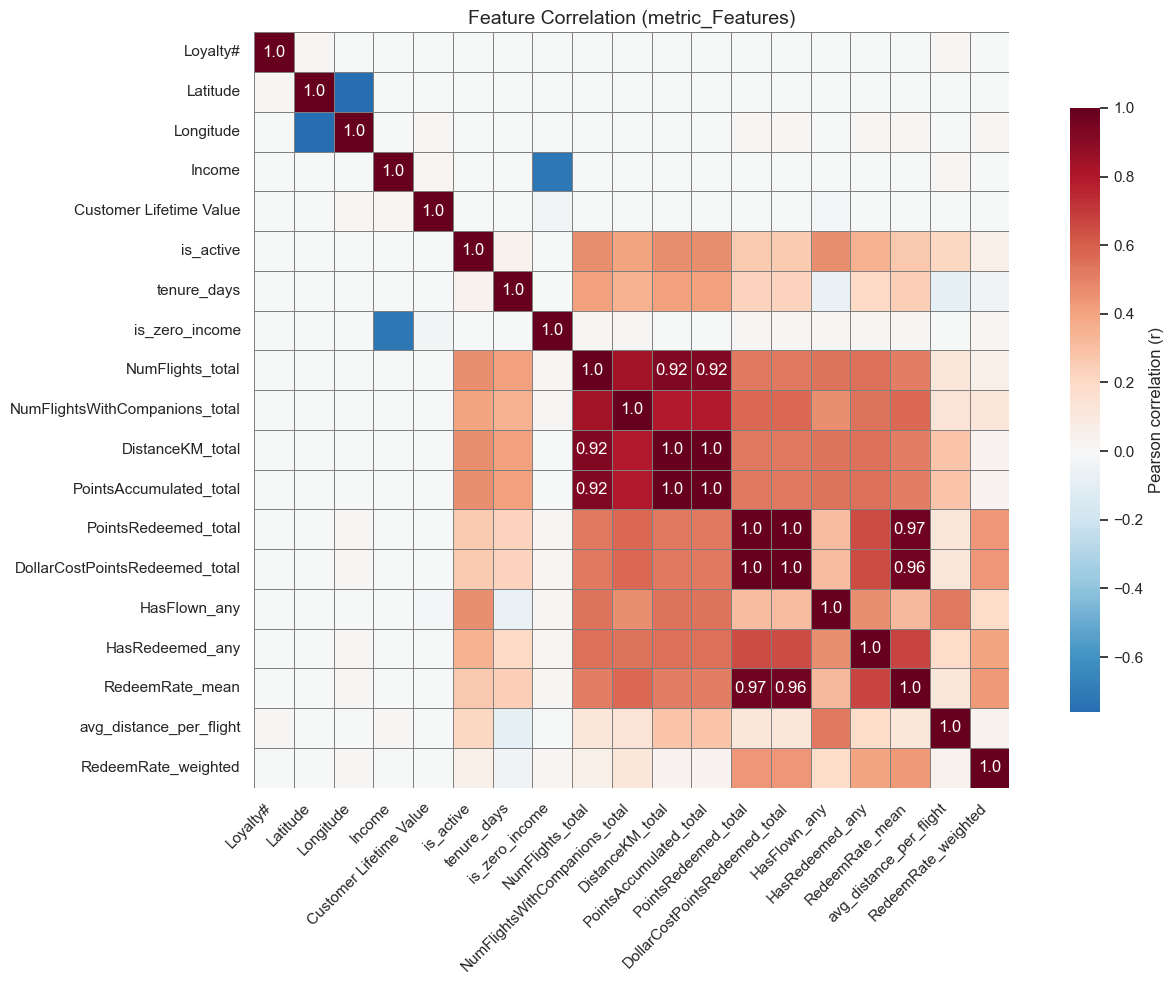

In [138]:
corr = merged[metric_Features].corr(method='pearson').round(2)
annot_array = np.where(np.abs(corr.values) >= 0.9, corr.values, "")

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    center=0,
    cmap='RdBu_r',
    annot=annot_array,
    fmt='s',
    square=True,
    linewidths=.5,
    linecolor='gray',
    cbar_kws={'shrink': 0.8, 'label': 'Pearson correlation (r)'}
)

plt.title("Feature Correlation (metric_Features)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



#### Feature Summary: Keep or Drop

| **Feature**                     | **Keep or Drop** | **Reason**                                      |
|---------------------------------|------------------|-------------------------------------------------|
| Loyalty#                        | Drop             | Identifier only, not useful for prediction     |
| Latitude, Longitude             | Drop             | Location info, weak correlation with behavior  |
| NumFlights_total                | Keep             | Best measure of flight activity                |
| DistanceKM_total                | Drop             | Highly correlated with NumFlights_total        |
| PointsAccumulated_total         | Drop             | Highly correlated with flight totals           |
| PointsRedeemed_total            | Drop             | Highly correlated with  RedeemRate_weighted    |              |
| DollarCostPointsRedeemed_total  | Drop             | Highly correlated with PointsRedeemed_total    |
| HasFlown_any, HasRedeemed_any   | keep             | Redundant but Shows customers behavior         |
| avg_distance_per_flight         | Keep             | Shows travel pattern (short vs long trips)    |
| RedeemRate_weighted             | Keep             | Strong indicator of loyalty engagement        |
| RedeemRate_mean                 | Drop             | Less important than weighted rate             |
| Income                          | Keep             | Important demographic feature                 |
| Customer Lifetime Value         | Keep             | Key business metric                           |
| is_active, tenure_days          | Keep             | Shows account status and membership duration  |
| is_zero_income                  | Keep             | Useful for segmentation                       |
| NumFlightsWithCompanions_total  | Keep             | Redundant but Shows customers behavior 

According to the above insights , we decided to drop the following features :

In [140]:
merged.columns

Index(['Loyalty#', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'Location Code', 'EnrollmentDateOpening', 'CancellationDate',
       'Customer Lifetime Value', 'EnrollmentType', 'is_active',
       'income_category', 'tenure_days', 'is_zero_income', 'NumFlights_total',
       'NumFlightsWithCompanions_total', 'DistanceKM_total',
       'PointsAccumulated_total', 'PointsRedeemed_total',
       'DollarCostPointsRedeemed_total', 'periods_nunique', 'first_period',
       'last_period', 'HasFlown_any', 'HasRedeemed_any', 'RedeemRate_mean',
       'avg_distance_per_flight', 'RedeemRate_weighted', 'last_year',
       'last_month'],
      dtype='object')

In [141]:
merged = merged.drop(columns=[
   'Loyalty#', 'Province or State', 'City', 'Latitude', 'Longitude',
       'EnrollmentDateOpening', 'CancellationDate',
       'income_category','DistanceKM_total',
       'PointsAccumulated_total', 'PointsRedeemed_total',
       'DollarCostPointsRedeemed_total', 'periods_nunique', 'first_period',
       'last_period',  'RedeemRate_mean',
    'last_year' , 'last_month'
], errors='ignore')



In [142]:
merged.columns

Index(['Gender', 'Education', 'Income', 'Marital Status', 'LoyaltyStatus',
       'Location Code', 'Customer Lifetime Value', 'EnrollmentType',
       'is_active', 'tenure_days', 'is_zero_income', 'NumFlights_total',
       'NumFlightsWithCompanions_total', 'HasFlown_any', 'HasRedeemed_any',
       'avg_distance_per_flight', 'RedeemRate_weighted'],
      dtype='object')

In [143]:
num_cols = merged.select_dtypes(include=['number']).columns.tolist()

cat_cols = merged.select_dtypes(include=['object', 'category']).columns.tolist()

bool_cols = merged.select_dtypes(include=['bool']).columns.tolist()
datetime_cols = merged.select_dtypes(include=['datetime']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)
print("Boolean:", bool_cols)
print("Datetime:", datetime_cols)


Numerical: ['Income', 'Customer Lifetime Value', 'is_active', 'tenure_days', 'is_zero_income', 'NumFlights_total', 'NumFlightsWithCompanions_total', 'HasFlown_any', 'HasRedeemed_any', 'avg_distance_per_flight', 'RedeemRate_weighted']
Categorical: ['Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'Location Code', 'EnrollmentType']
Boolean: []
Datetime: []


#### ENCODING :

In [144]:
cat_cols = merged.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical:", cat_cols)


Categorical: ['Gender', 'Education', 'Marital Status', 'LoyaltyStatus', 'Location Code', 'EnrollmentType']


In [145]:
cat_cols = merged.select_dtypes(include=['object', 'category']).columns.unique().tolist()

merged[cat_cols] = merged[cat_cols].apply(lambda s: s.astype('category'))

categories_by_col = {
    col: merged[col].cat.categories.tolist()
    for col in cat_cols
}
for col, cats in categories_by_col.items():
    print(f"=== {col} ===")
    print(f"Number of categories: {len(cats)}")
    print(cats)
    print()


=== Gender ===
Number of categories: 2
['female', 'male']

=== Education ===
Number of categories: 5
['Bachelor', 'College', 'Doctor', 'High School or Below', 'Master']

=== Marital Status ===
Number of categories: 3
['Divorced', 'Married', 'Single']

=== LoyaltyStatus ===
Number of categories: 3
['Aurora', 'Nova', 'Star']

=== Location Code ===
Number of categories: 3
['Rural', 'Suburban', 'Urban']

=== EnrollmentType ===
Number of categories: 2
['2021 Promotion', 'Standard']



In [146]:
#  Define encoding strategies

binary_maps = {
    'Gender': {'female': 0, 'male': 1},
    'EnrollmentType': {'2021 Promotion': 0, 'Standard': 1}
}

ordinal_orders = {
    'Education': [
        'High School or Below',
        'College',
        'Bachelor',
        'Master',
        'Doctor'
    ],
    'LoyaltyStatus': [
        'Star',
        'Nova',
        'Aurora'
    ]
}

cat_cols_existing = merged.select_dtypes(
    include=['object', 'category']
).columns.tolist()

reserved_for_binary = list(binary_maps.keys())
reserved_for_ordinal = list(ordinal_orders.keys())

one_hot_cols = [
    c for c in cat_cols_existing
    if c not in reserved_for_binary + reserved_for_ordinal
]

# Binary Encoding

for col, mapping in binary_maps.items():
    merged[col] = merged[col].map(mapping)

#  Ordinal Encoding


ordinal_encoder = OrdinalEncoder(
    categories=[ordinal_orders[col] for col in ordinal_orders],
    dtype=int
)

merged[list(ordinal_orders.keys())] = ordinal_encoder.fit_transform(
    merged[list(ordinal_orders.keys())]
)


#  One-Hot Encoding

merged = pd.get_dummies(
    merged,
    columns=one_hot_cols,
    drop_first=True
)


merged.head()

,Gender,Education,Income,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,is_active,tenure_days,is_zero_income,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,avg_distance_per_flight,RedeemRate_weighted,Marital Status_Married,Marital Status_Single,Location Code_Suburban,Location Code_Urban
0,0,2,70146.0,0,3839.14,1,1,1050,0,189.6,56.1,1.0,1.0,2674.340190,0.266628,True,False,False,True
1,1,1,0.0,0,3839.61,1,1,1028,1,279.1,32.2,1.0,1.0,1529.299176,0.526282,False,False,False,False
2,1,1,0.0,0,3839.75,1,0,1631,1,120.0,39.9,1.0,1.0,1986.467500,0.229922,False,True,False,True
3,1,1,0.0,0,3839.75,1,1,2144,1,195.9,58.5,1.0,1.0,1970.542624,0.423144,False,True,True,False
4,1,2,97832.0,0,3842.79,0,1,1528,0,170.7,62.9,1.0,0.0,2163.108377,0.000000,True,False,True,False


#### SCALING :

In [137]:
#Applying Standard Scaling : 

In [147]:
num_cols =  ['Income', 'Customer Lifetime Value', 'is_active',
                        'tenure_days', 'is_zero_income', 'NumFlights_total', 'NumFlightsWithCompanions_total', 
                        'HasFlown_any', 'HasRedeemed_any', 'avg_distance_per_flight', 'RedeemRate_weighted']

In [148]:
merged[num_cols].describe(include='all')
merged[num_cols].isna().sum()

Income                            0
Customer Lifetime Value           0
is_active                         0
tenure_days                       0
is_zero_income                    0
NumFlights_total                  0
NumFlightsWithCompanions_total    0
HasFlown_any                      0
HasRedeemed_any                   0
avg_distance_per_flight           0
RedeemRate_weighted               0
dtype: int64

In [150]:
scaler = StandardScaler()
merged[num_cols] = scaler.fit_transform(merged[num_cols])
merged[num_cols].head()

,Income,Customer Lifetime Value,is_active,tenure_days,is_zero_income,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,avg_distance_per_flight,RedeemRate_weighted
0,1.066513,-0.604887,0.395693,-0.184176,-0.581700,0.560210,0.833817,0.314929,0.668768,0.624422,-0.041820
1,-1.243346,-0.604818,0.395693,-0.214774,1.719099,1.630814,-0.155595,0.314929,0.668768,-0.360537,0.495822
2,-1.243346,-0.604798,-2.527212,0.623883,1.719099,-0.272348,0.163170,0.314929,0.668768,0.032717,-0.117824
3,-1.243346,-0.604798,0.395693,1.337367,1.719099,0.635571,0.933172,0.314929,0.668768,0.019019,0.282263
4,1.978193,-0.604355,0.395693,0.480630,-0.581700,0.334128,1.115324,0.314929,-1.495286,0.184663,-0.593903


In [161]:
final_df = merged.copy()
final_df.head()

,Gender,Education,Income,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,is_active,tenure_days,is_zero_income,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,avg_distance_per_flight,RedeemRate_weighted,Marital Status_Married,Marital Status_Single,Location Code_Suburban,Location Code_Urban
0,0,2,1.066513,0,-0.604887,1,0.395693,-0.184176,-0.581700,0.560210,0.833817,0.314929,0.668768,0.624422,-0.041820,True,False,False,True
1,1,1,-1.243346,0,-0.604818,1,0.395693,-0.214774,1.719099,1.630814,-0.155595,0.314929,0.668768,-0.360537,0.495822,False,False,False,False
2,1,1,-1.243346,0,-0.604798,1,-2.527212,0.623883,1.719099,-0.272348,0.163170,0.314929,0.668768,0.032717,-0.117824,False,True,False,True
3,1,1,-1.243346,0,-0.604798,1,0.395693,1.337367,1.719099,0.635571,0.933172,0.314929,0.668768,0.019019,0.282263,False,True,True,False
4,1,2,1.978193,0,-0.604355,0,0.395693,0.480630,-0.581700,0.334128,1.115324,0.314929,-1.495286,0.184663,-0.593903,True,False,True,False


# 5.Clustering Methods and Results

Before applying clustering, the features were grouped based on their purpose to avoid mixing different types of information. Behavioral features were used for clustering because they directly describe how customers travel and interact with the loyalty program. Value and engagement features were analyzed separately to understand customer importance and retention. Demographic features were not used to create the clusters; instead, they were used after clustering to describe and interpret each customer group. This approach helps produce clearer, more meaningful, and business-relevant customer segments

behavioral_features :

In [155]:
behavioral_features = [
    'NumFlights_total',
    'NumFlightsWithCompanions_total',
    'HasFlown_any',
    'HasRedeemed_any',
    'RedeemRate_weighted',
    'avg_distance_per_flight'
]

X_behavioral = final_df[behavioral_features]

value_features :

In [210]:
value_features = [
    'Customer Lifetime Value',
    'tenure_days',
    'is_active',
]

X_value = final_df[value_features]

### Behavioral Segmentation :
#### 1. K - Means Clustering :

In [157]:
behavioral_features = [
    'NumFlights_total',
    'NumFlightsWithCompanions_total',
    'HasFlown_any',
    'HasRedeemed_any',
    'RedeemRate_weighted',
    'avg_distance_per_flight'
]

X_behavioral = final_df[behavioral_features]
X_behavioral.describe()

,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,RedeemRate_weighted,avg_distance_per_flight
count,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04
mean,5.281459e-17,-2.848309e-17,1.929703e-16,1.032118e-16,1.162446e-16,1.122507e-16
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.707794e+00,-1.488610e+00,-3.175315e+00,-1.495286e+00,-5.939033e-01,-1.676034e+00
25%,-8.692545e-01,-8.262419e-01,3.149294e-01,-1.495286e+00,-5.939033e-01,-2.775909e-01
50%,2.432160e-01,3.483618e-02,3.149294e-01,6.687685e-01,-1.493303e-01,2.536063e-02
75%,7.336601e-01,7.013438e-01,3.149294e-01,6.687685e-01,2.741625e-01,3.312686e-01
max,4.744535e+00,4.501679e+00,3.149294e-01,6.687685e-01,6.829059e+01,2.574271e+01


To determine a reasonable number of clusters, we analyze the inertia, which measures within-cluster sum of squares.

In [162]:
X_behavioral = final_df[behavioral_features]

In [165]:
range_clusters = range(2, 11)
inertia = []

for k in range_clusters:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=42
    )
    km.fit(X_behavioral)
    inertia.append(km.inertia_)


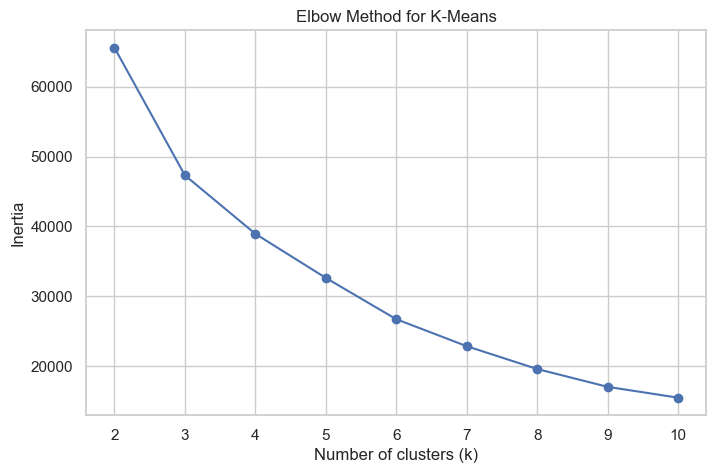

In [166]:
plt.figure(figsize=(8,5))
plt.plot(range_clusters, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.xticks(range_clusters)
plt.show()


The optimal number of clusters is suggested by the elbow point, where adding more clusters leads to diminishing returns in inertia reduction.

To complement the elbow method, we compute the average silhouette score, which measures cluster cohesion and separation. 

In [188]:
sil_scores = []

for k in range(2, 11):
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=1
    )

    labels = km.fit_predict(X_behavioral)

    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_behavioral, labels)
        sil_scores.append(score)
        print(f"k={k}, silhouette={score:.3f}")
    else:
        print(f"k={k}, only one cluster formed")

k=2, silhouette=0.488
k=3, silhouette=0.507
k=4, silhouette=0.416
k=5, silhouette=0.417
k=6, silhouette=0.403
k=7, silhouette=0.422
k=8, silhouette=0.385
k=9, silhouette=0.386
k=10, silhouette=0.379


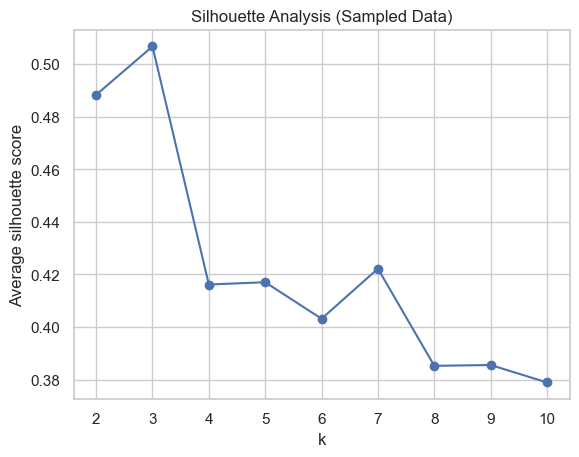

In [189]:
plt.plot(range_clusters, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Analysis (Sampled Data)")
plt.show()


Based on the elbow and silhouette analyses, we select K = 3 clusters.

In [190]:
optimal_k = 3 

final_kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=10,
    random_state=1
)

final_df['kmeans_cluster'] = final_kmeans.fit_predict(X_behavioral)


To interpret the clusters, we compute the mean profile of each cluster.

In [191]:
cluster_profile = (
    final_df
    .groupby('kmeans_cluster')[behavioral_features ]
    .mean()
)

cluster_profile


,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,RedeemRate_weighted,avg_distance_per_flight
kmeans_cluster,,,,,,
0,-0.484218,-0.551320,0.314929,-1.488819,-0.590315,0.308504
1,0.375100,0.367639,0.314929,0.663587,0.263245,0.121449
2,-1.707794,-1.488610,-3.175315,-1.495286,-0.593903,-1.676034


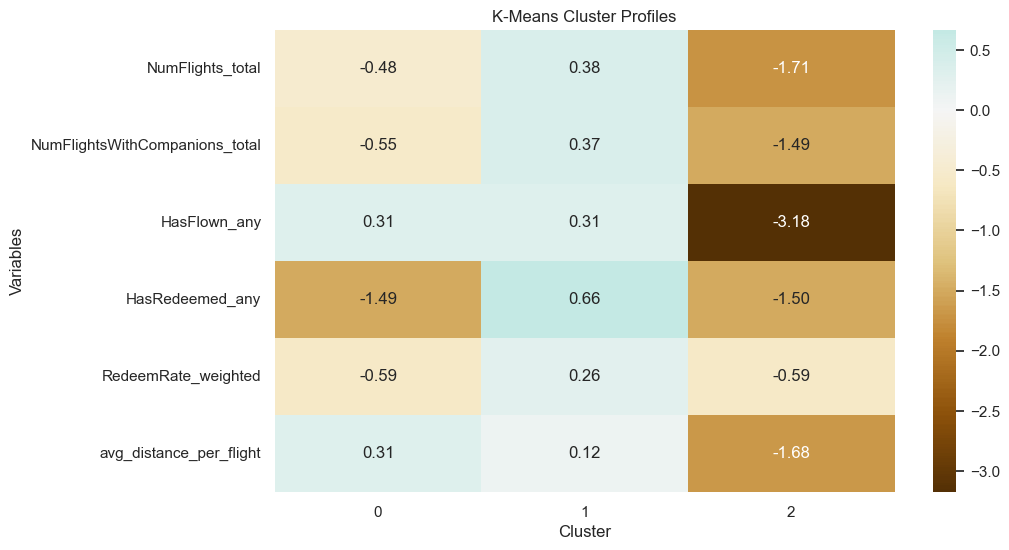

In [192]:
plt.figure(figsize=(10,6))
sns.heatmap(
    cluster_profile.T,
    annot=True,
    cmap="BrBG",
    center=0,
    fmt=".2f"
)
plt.title("K-Means Cluster Profiles")
plt.xlabel("Cluster")
plt.ylabel("Variables")
plt.show()


### K-Means Cluster Interpretation (Behavioral Segmentation)

The K-Means algorithm identified three distinct customer segments based on behavioral features related to travel activity and loyalty engagement. Since all features were standardized, positive values indicate above-average behavior, while negative values indicate below-average behavior compared to the overall customer base.

**Cluster 0 – Occasional Travelers with Low Loyalty Engagement**  
Customers in this cluster travel occasionally but show limited interaction with the loyalty program. Their number of flights and travel distance are slightly below average, and their redemption activity is clearly lower than average. This group represents customers who use the airline services but are not actively engaged with rewards or loyalty benefits.

**Cluster 1 – Highly Engaged and Loyal Customers**  
This cluster represents the most valuable and engaged customers. Members of this group have above-average flight activity, frequently travel with companions, and show the highest redemption rates. They actively use the loyalty program and respond well to reward-based incentives.

**Cluster 2 – Inactive or Dormant Customers**  
Customers in this cluster show very low travel activity and minimal engagement with the loyalty program. Most members rarely fly, have very low redemption behavior, and travel shorter distances. This group represents inactive or churn-risk customers.


#### 2.Hierarchical clustering

In [176]:
behavioral_features = [
    'NumFlights_total',
    'NumFlightsWithCompanions_total',
    'HasFlown_any',
    'HasRedeemed_any',
    'RedeemRate_weighted',
    'avg_distance_per_flight'
]

X_behavioral = final_df[behavioral_features]
X_behavioral.describe()

,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,RedeemRate_weighted,avg_distance_per_flight
count,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04
mean,5.281459e-17,-2.848309e-17,1.929703e-16,1.032118e-16,1.162446e-16,1.122507e-16
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.707794e+00,-1.488610e+00,-3.175315e+00,-1.495286e+00,-5.939033e-01,-1.676034e+00
25%,-8.692545e-01,-8.262419e-01,3.149294e-01,-1.495286e+00,-5.939033e-01,-2.775909e-01
50%,2.432160e-01,3.483618e-02,3.149294e-01,6.687685e-01,-1.493303e-01,2.536063e-02
75%,7.336601e-01,7.013438e-01,3.149294e-01,6.687685e-01,2.741625e-01,3.312686e-01
max,4.744535e+00,4.501679e+00,3.149294e-01,6.687685e-01,6.829059e+01,2.574271e+01


In [223]:
n_clusters = 3  
hclust = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=n_clusters
)

labels = hclust.fit_predict(X_behavioral)


Cluster Means:

labels                                 0         1         2
NumFlights_total                0.366980 -1.707794 -0.460219
NumFlightsWithCompanions_total  0.359118 -1.488610 -0.526171
HasFlown_any                    0.314929 -3.175315  0.314929
HasRedeemed_any                 0.664146 -1.495286 -1.495286
RedeemRate_weighted             0.263788 -0.593903 -0.593903
avg_distance_per_flight         0.156932 -1.676034  0.195856


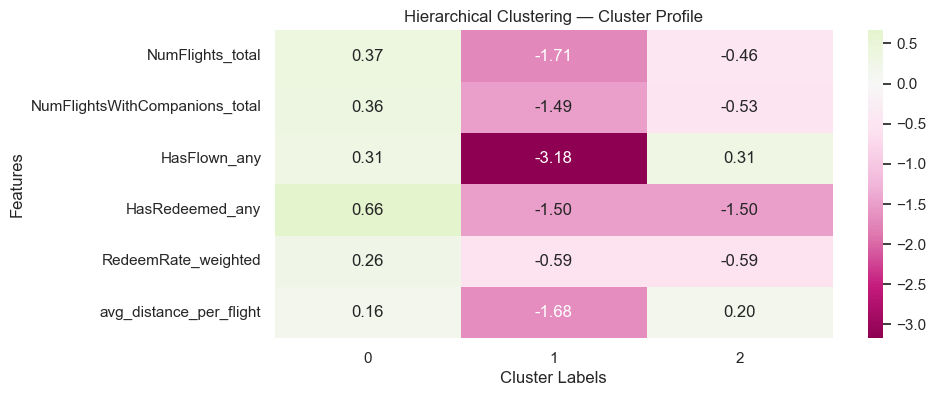

In [225]:
df_labeled = pd.concat(
    [X_behavioral.reset_index(drop=True),
     pd.Series(labels, name='labels')],
    axis=1
)

cluster_means = df_labeled.groupby('labels').mean().T
print("\nCluster Means:\n")
print(cluster_means)

plt.figure(figsize=(9,4))
sns.heatmap(cluster_means, annot=True, center=0, cmap="PiYG", fmt=".2f")
plt.title("Hierarchical Clustering — Cluster Profile")
plt.xlabel("Cluster Labels")
plt.ylabel("Features")
plt.show()


### Hierarchical Clustering – Cluster Interpretation

Hierarchical clustering using Ward linkage was applied on the standardized behavioral features to validate the segmentation structure obtained from K-Means. The resulting clusters show clear differences in travel frequency, companion travel, and loyalty program engagement.

Cluster 0 represents highly engaged and loyal customers, characterized by frequent flights, higher redemption activity, and consistent travel behavior. Cluster 1 includes low-engagement customers with minimal flight activity and very limited interaction with the loyalty program, indicating a higher churn risk. Cluster 2 captures occasional travelers who have flown before but show limited loyalty engagement.

Overall, the hierarchical clustering results strongly align with the K-Means segmentation, confirming the robustness and stability of the identified behavioral customer segments.

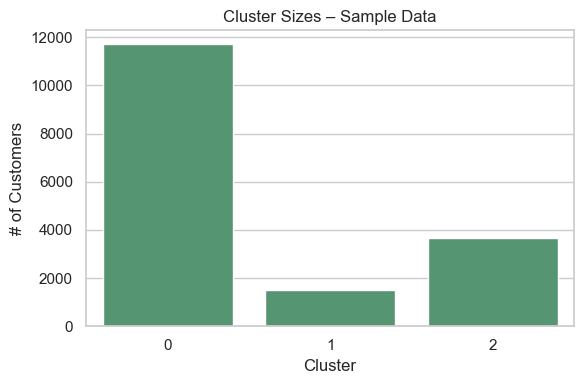

In [226]:
cluster_sizes = df_labeled['labels'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, color="#4c9f70")
plt.title("Cluster Sizes – Sample Data")
plt.xlabel("Cluster")
plt.ylabel("# of Customers")
plt.tight_layout()
plt.show()


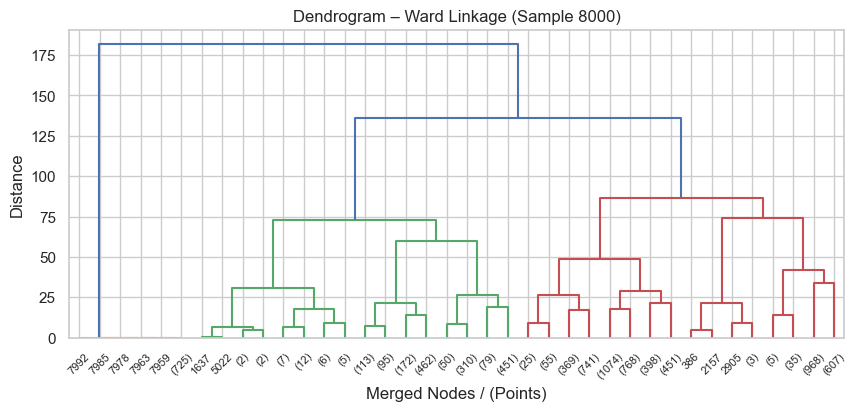

In [227]:
Z = linkage(df_sample, method='ward')

plt.figure(figsize=(10,4))
dendrogram(Z, truncate_mode="level", p=5)
plt.title("Dendrogram – Ward Linkage (Sample 8000)")
plt.xlabel("Merged Nodes / (Points)")
plt.ylabel("Distance")
plt.show()

The dendrogram shows clear separation between major branches at higher distance levels, suggesting the presence of a small number of distinct clusters. Cutting the dendrogram at a higher distance level indicates the formation of *three main clusters*, which is consistent with the optimal number of clusters identified using K-Means and silhouette analysis.


#### 3.DBSCAN :

In [202]:
behavioral_features = [
    'NumFlights_total',
    'NumFlightsWithCompanions_total',
    'HasFlown_any',
    'HasRedeemed_any',
    'RedeemRate_weighted',
    'avg_distance_per_flight'
]

X_behavioral = final_df[behavioral_features]
X_behavioral.describe()

,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,RedeemRate_weighted,avg_distance_per_flight
count,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04,1.690100e+04
mean,5.281459e-17,-2.848309e-17,1.929703e-16,1.032118e-16,1.162446e-16,1.122507e-16
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.707794e+00,-1.488610e+00,-3.175315e+00,-1.495286e+00,-5.939033e-01,-1.676034e+00
25%,-8.692545e-01,-8.262419e-01,3.149294e-01,-1.495286e+00,-5.939033e-01,-2.775909e-01
50%,2.432160e-01,3.483618e-02,3.149294e-01,6.687685e-01,-1.493303e-01,2.536063e-02
75%,7.336601e-01,7.013438e-01,3.149294e-01,6.687685e-01,2.741625e-01,3.312686e-01
max,4.744535e+00,4.501679e+00,3.149294e-01,6.687685e-01,6.829059e+01,2.574271e+01


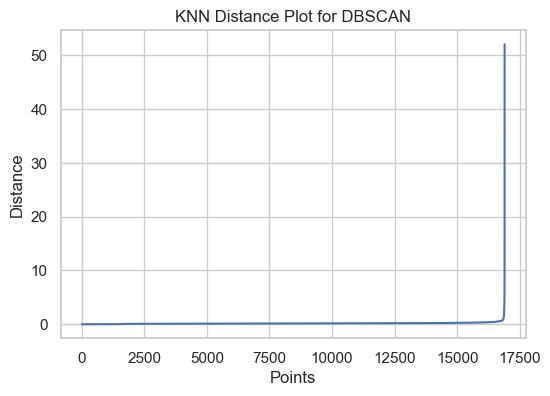

In [204]:
nbrs = NearestNeighbors(n_neighbors=5)
nbrs.fit(X_behavioral)

distances, _ = nbrs.kneighbors(X_behavioral)
distances = np.sort(distances[:, 4])

plt.figure(figsize=(6,4))
plt.plot(distances)
plt.title("KNN Distance Plot for DBSCAN")
plt.xlabel("Points")
plt.ylabel("Distance")
plt.show()

In [206]:
dbscan = DBSCAN(
    eps=0.8,      
    min_samples=5
)

db_labels = dbscan.fit_predict(X_behavioral)

pd.Series(db_labels).value_counts()

 0    11635
 1     3671
 2     1525
-1       55
 3       10
 4        5
Name: count, dtype: int64

In [208]:
X_dbscan = X_behavioral.copy()
X_dbscan['dbscan_cluster'] = db_labels

X_dbscan.groupby('dbscan_cluster').mean()

,NumFlights_total,NumFlightsWithCompanions_total,HasFlown_any,HasRedeemed_any,RedeemRate_weighted,avg_distance_per_flight
dbscan_cluster,,,,,,
-1,-1.176027,-0.897522,0.314929,0.196611,7.371175,5.099169
0,0.376568,0.367078,0.314929,0.668768,0.231149,0.118429
1,-0.459555,-0.525681,0.314929,-1.495286,-0.593903,0.191426
2,-1.707794,-1.488610,-3.175315,-1.495286,-0.593903,-1.676034
3,-1.683392,-1.436448,0.314929,-1.495286,-0.593903,10.415008
4,-1.688894,-1.463771,0.314929,-1.495286,-0.593903,18.140900


The results showed limited cluster separation and a relatively high proportion of noise points. Therefore, DBSCAN was not selected as the primary clustering method, and K-Means was retained for the final segmentation.

### Comparison of Clustering Methods

Three clustering approaches were applied using the same standardized behavioral features: **K-Means, Hierarchical Clustering (Ward linkage), and DBSCAN**. **K-Means** produced the clearest and most interpretable customer segments, supported by elbow and silhouette analysis, and was selected as the primary segmentation method.

**Hierarchical clustering** confirmed the stability of the segmentation structure, revealing similar behavioral patterns and reinforcing the validity of the K-Means results. The dendrogram provided additional visual insight into cluster separation but was less scalable for large datasets.

**DBSCAN** was applied to detect density-based patterns and identify noise points. While it successfully highlighted a small number of outliers, the majority of customers were grouped into large, uneven clusters, limiting its usefulness for business-oriented segmentation.

Overall, **K-Means** was chosen as the final clustering solution due to its interpretability, stability, and practical relevance, with Hierarchical clustering serving as validation and DBSCAN as a complementary robustness check.

### Value_based Segmentation :

In [198]:
final_df.columns

Index(['Gender', 'Education', 'Income', 'LoyaltyStatus',
       'Customer Lifetime Value', 'EnrollmentType', 'is_active', 'tenure_days',
       'is_zero_income', 'NumFlights_total', 'NumFlightsWithCompanions_total',
       'HasFlown_any', 'HasRedeemed_any', 'avg_distance_per_flight',
       'RedeemRate_weighted', 'Marital Status_Married',
       'Marital Status_Single', 'Location Code_Suburban',
       'Location Code_Urban', 'kmeans_cluster'],
      dtype='object')

In [219]:
final_df.groupby('kmeans_cluster')[
    ['Customer Lifetime Value', 'tenure_days', 'is_active']
].mean()

,Customer Lifetime Value,tenure_days,is_active
kmeans_cluster,,,
0,-0.009282,-0.515679,-0.155379
1,-0.004290,0.135669,0.239738
2,0.055303,0.204306,-1.463466


This table summarizes value_based features across the behavioral clusters. Cluster 1 represents loyal and active customers, Cluster 0 includes low-value customers with higher churn risk, and Cluster 2 consists of high-value customers who are currently inactive and therefore at risk of churn.

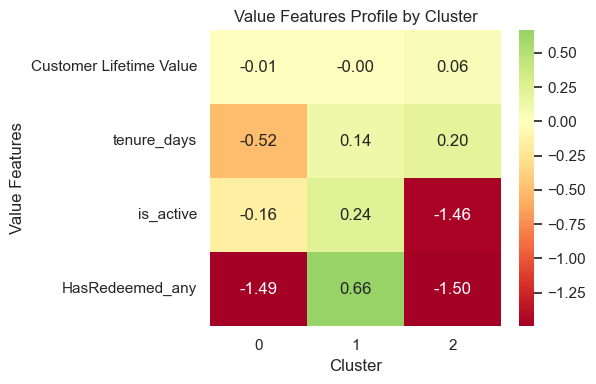

In [220]:
plt.figure(figsize=(6,4))
sns.heatmap(
    value_summary.T,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)
plt.title("Value Features Profile by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Value Features")
plt.tight_layout()
plt.show()

The heatmap highlights clear differences in customer value and churn risk across the clusters.

### Demographic segmentation : (Profiling)

In [240]:

demographic_features = [
    'Income',
    'is_zero_income',
    'Gender',
    'Education',
    'EnrollmentType',
    'Marital Status_Married',	'Marital Status_Single' ,	'Location Code_Suburban',	'Location Code_Urban'
]

demographic_profile = (
    final_df
    .groupby('kmeans_cluster')[demographic_features]
    .mean(numeric_only=True)
    .round(3)
)

demographic_profile


,Income,is_zero_income,Education,Marital Status_Married,Marital Status_Single,Location Code_Suburban,Location Code_Urban
kmeans_cluster,,,,,,,
0,0.007,0.004,1.768,0.578,0.270,0.340,0.319
1,-0.004,0.005,1.769,0.579,0.270,0.338,0.329
2,0.012,-0.048,1.799,0.609,0.248,0.332,0.335


The table summarizes the demographic characteristics of each behavioral cluster. Overall, demographic differences across clusters are relatively limited. Income levels, education, marital status, and location show only minor variations between clusters.

This indicates that the customer segmentation is primarily driven by behavioral factors rather than demographic attributes. Therefore, demographic features are used solely to enrich the interpretation of the behavioral clusters, without influencing the cluster formation.

#### Final Insights and Business Recommendations :

### Insights:

- **1- Three Distinct Behavioral Segments Identified**

Cluster 1 (Highly Engaged Travelers): Frequent flyers, high redemption activity, strong loyalty engagement. These customers are the backbone of the loyalty program.
Cluster 0 (Occasional Travelers): Moderate flight activity, low redemption rates. They represent an opportunity for upselling and engagement campaigns.
Cluster 2 (Inactive/Dormant Customers): Minimal flight activity and loyalty interaction. High churn risk.

- **2-Value-Based Differences Across Clusters**

Cluster 1 shows higher tenure and active status, making them ideal for retention strategies.
Cluster 2 includes inactive but high-value customers, suggesting targeted win-back campaigns could recover significant revenue.

- **3-Low Redemption Engagement Overall**

94% of customers never redeemed points, indicating a major gap in loyalty program awareness or perceived value.
Opportunity: Simplify redemption process and promote benefits through personalized campaigns.


- **4-Travel Behavior Insights**

Toronto, Vancouver, and Montreal dominate as origin cities for travelers.
Seasonal trends show slightly higher engagement in late-year months, which can guide promotional timing.

- **5-Demographics Play a Minor Role**

Income and education levels show limited variation across clusters.
Segmentation is primarily driven by behavioral factors, reinforcing the need for activity-based targeting rather than demographic-only strategies.

- **6- Churn Risk Indicators**

Customers with zero income and short tenure are more likely to be inactive.
Early engagement programs for new enrollees can reduce churn.


### Business Recommendations :

- Retention & Upsell: Offer exclusive perks to Cluster 1 to maintain loyalty and encourage premium services.
- Reactivation Campaigns: Target Cluster 2 with personalized offers (e.g., bonus points for first flight after inactivity).
- Increase Redemption Awareness: Launch educational campaigns and simplify redemption options to boost engagement.
- Seasonal Promotions: Focus marketing efforts in Q4 when travel activity peaks.
- Data-Driven Personalization: Use behavioral segmentation for tailored communication instead of generic demographic-based campaigns.

The End ..Thank you